# **Replicating Känzig (2021): Constructing and Validating the Oil Supply News Instrument in Python**

This section replicates the construction and empirical validation of the oil supply news instrument proposed by Känzig (2021) using the publicly available replication files. The original WTI-based instrument is first reconstructed in Python and validated against Känzig's MATLAB benchmark. The same methodology is then applied to Brent crude oil futures to construct an alternative Brent-based oil supply news instrument.

The analysis proceeds in seven stages:

1. Load and clean daily WTI and Brent futures prices and match them to OPEC announcement dates.

2. Compute announcement-day futures-price surprises across different contract maturities.

3. Extract the common movement in the futures curve using Principal Component Analysis (PCA).

4. Construct the monthly WTI oil supply news instrument and validate the Python replication against Känzig's MATLAB benchmark.

5. Apply the same procedure to Brent futures to construct and validate the monthly Brent oil supply news instrument.

6. Compare the WTI- and Brent-based instruments using descriptive statistics, correlation analysis, time-series evidence, and the largest historical oil supply news shocks.

7. Validate the Python Proxy-SVAR implementation by reproducing Känzig's baseline U.S. impulse responses and examine the sensitivity of the estimated transmission mechanism to the shorter 1991–2017 sample used in the subsequent German application.

## **1. Import Required Packages**

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from scipy.io import loadmat
import matplotlib.pyplot as plt
import math
import statsmodels.api as sm


In [2]:
# Importing files
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "Data for Replication"
DATA_DIR_G = PROJECT_DIR / "Data Germany"
OUTPUT_DIR = PROJECT_DIR / "output"

# Daily oil futures prices (WTI and Brent): sourced from Känzig
FUTURES_FILE = DATA_DIR / "Oilfutures.xlsx"

# OPEC announcement dates used for the WTI instrument: sourced from Känzig
WTI_ANNOUNCEMENTS_FILE = (DATA_DIR / "OPECAnnouncements.xlsx")
# OPEC announcement dates adjusted for European trading hours, used for the Brent instrument
BRENT_ANNOUNCEMENTS_FILE =  (DATA_DIR / "OPECannouncementsEU.xlsx")

# MATLAB benchmark series used for validation
WTI_BENCHMARK_FILE = (DATA_DIR / "OilSurprisesMLog.mat")    
BRENT_BENCHMARK_FILE = (DATA_DIR / "OilSurprisesMLogBrent.mat")

## **2. Import and Clean Data**
Sections 2.1. and 2.2. import and clean oil futures prices and OPEC announcement data.

### **2.1. Daily Oil Futures Prices**

The "POIL" worksheet contains daily settlement prices for WTI and Brent futures contracts. It is structured as follows:

- Row 0 contains Bloomberg variable names.
- Row 1 contains Bloomberg ticker codes.
- Row 2 onward contains daily prices.
- Column 0 contains the date.
- Columns 1–24 contain WTI futures contracts.
- Columns 25–48 contain Brent futures contracts.

The data are imported without predefined column headers. The Bloomberg variable names in the first row are then assigned as column names, while the two metadata rows are removed. Dates and futures prices are converted to appropriate data types before the observations are sorted chronologically.

In [3]:
# Reading the futures-price sheet without assigning headers
raw_futures = pd.read_excel(
    FUTURES_FILE,
    sheet_name="POIL",
    header=None,
)

# The first row contains the Bloomberg variable names
futures_column_names = raw_futures.iloc[0].tolist()
futures_column_names[0] = "Date"

# Remove first two metadata rows
futures = raw_futures.iloc[2:].copy()

# Assign the variable names extracted from the first row
futures.columns = futures_column_names

# Convert the date column to pandas datetime format
# Any invalid values are converted to NaT
futures["Date"] = pd.to_datetime(
    futures["Date"],
    errors="coerce",
)

# Identify all columns other than the date column
futures_price_columns = futures.columns.drop("Date")

# Convert all futures-price columns to numeric values
# Any non-numeric entries are converted to NaN
futures[futures_price_columns] = futures[
    futures_price_columns
].apply(
    pd.to_numeric,
    errors="coerce",
)

# Remove rows that do not contain a valid date and reset the index
futures = (
    futures
    .dropna(subset=["Date"])
    .sort_values("Date")
    .reset_index(drop=True)
)

print("Cleaned futures data:")
display(futures.head())
print("Futures dataset dimensions:", futures.shape)
print("First futures observation:", futures["Date"].min())
print("Last futures observation:", futures["Date"].max())


Cleaned futures data:


,Date,"DPL#(NCLC.01(PS),6)","DPL#(NCLC.02(PS),6)","DPL#(NCLC.03(PS),6)","DPL#(NCLC.04(PS),6)","DPL#(NCLC.05(PS),6)","DPL#(NCLC.06(PS),6)","DPL#(NCLC.07(PS),6)","DPL#(NCLC.08(PS),6)","DPL#(NCLC.09(PS),6)",...,"DPL#(LLCC.15(PS),6)","DPL#(LLCC.16(PS),6)","DPL#(LLCC.17(PS),6)","DPL#(LLCC.18(PS),6)","DPL#(LLCC.19(PS),6)","DPL#(LLCC.20(PS),6)","DPL#(LLCC.21(PS),6)","DPL#(LLCC.22(PS),6)","DPL#(LLCC.23(PS),6)","DPL#(LLCC.24(PS),6)"
0,1983-03-30,29.39999,29.34999,29.25000,29.20000,28.95000,28.89999,28.75000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1983-03-31,29.26999,29.23999,29.04999,28.84999,28.75000,28.75000,28.59999,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1983-04-01,29.26999,29.23999,29.04999,28.84999,28.75000,28.75000,28.59999,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1983-04-04,29.43999,29.25000,29.09999,29.04999,28.95000,28.95000,28.84999,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1983-04-05,29.70999,29.53999,29.34999,29.20000,29.09999,29.00000,29.00000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Futures dataset dimensions: (9068, 49)
First futures observation: 1983-03-30 00:00:00
Last futures observation: 2017-12-29 00:00:00


### **2.2. Select the Futures Contracts Used in the Analysis**

Following Känzig (2021), the first 13 crude oil futures contracts are extracted for both WTI and Brent. These contracts span the front-month contract and the next twelve monthly maturities, covering approximately the first year of the futures curve where trading is most liquid and market participants respond most strongly to OPEC announcements.

The selected Bloomberg variables are extracted from the cleaned dataset and renamed using shorter, more intuitive labels.

In [4]:
# Bloomberg variable names for the first 13 WTI contracts
wti_bloomberg_columns = [
    f"DPL#(NCLC.{contract_number:02d}(PS),6)"
    for contract_number in range(1, 14)
]

# Bloomberg variable names for the first 13 Brent contracts
brent_bloomberg_columns = [
    f"DPL#(LLCC.{contract_number:02d}(PS),6)"
    for contract_number in range(1, 14)
]

# Check that all required columns are present in the workbook
missing_wti_columns = [
    column
    for column in wti_bloomberg_columns
    if column not in futures.columns
]

missing_brent_columns = [
    column
    for column in brent_bloomberg_columns
    if column not in futures.columns
]

if missing_wti_columns or missing_brent_columns:
    raise KeyError(
    "The futures workbook does not contain all required WTI and Brent contract columns."
    )

# Create separate WTI and Brent datasets
wti_futures = futures[
    ["Date"] + wti_bloomberg_columns
].copy()

brent_futures = futures[
    ["Date"] + brent_bloomberg_columns
].copy()

# Replace Bloomberg identifiers with simpler names
wti_futures.columns = (
    ["Date"]
    + [
        f"WTI_{contract_number:02d}"
        for contract_number in range(1, 14)
    ]
)

brent_futures.columns = (
    ["Date"]
    + [
        f"Brent_{contract_number:02d}"
        for contract_number in range(1, 14)
    ]
)

print(f"WTI dataset: {wti_futures.shape}")
display(wti_futures.head())

print(f"Brent dataset: {brent_futures.shape}")
display(brent_futures.head())

WTI dataset: (9068, 14)


,Date,WTI_01,WTI_02,WTI_03,WTI_04,WTI_05,WTI_06,WTI_07,WTI_08,WTI_09,WTI_10,WTI_11,WTI_12,WTI_13
0,1983-03-30,29.39999,29.34999,29.25000,29.20000,28.95000,28.89999,28.75000,NaN,NaN,NaN,NaN,NaN,NaN
1,1983-03-31,29.26999,29.23999,29.04999,28.84999,28.75000,28.75000,28.59999,NaN,NaN,NaN,NaN,NaN,NaN
2,1983-04-01,29.26999,29.23999,29.04999,28.84999,28.75000,28.75000,28.59999,NaN,NaN,NaN,NaN,NaN,NaN
3,1983-04-04,29.43999,29.25000,29.09999,29.04999,28.95000,28.95000,28.84999,NaN,NaN,NaN,NaN,NaN,NaN
4,1983-04-05,29.70999,29.53999,29.34999,29.20000,29.09999,29.00000,29.00000,NaN,NaN,NaN,NaN,NaN,NaN


Brent dataset: (9068, 14)


,Date,Brent_01,Brent_02,Brent_03,Brent_04,Brent_05,Brent_06,Brent_07,Brent_08,Brent_09,Brent_10,Brent_11,Brent_12,Brent_13
0,1983-03-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1983-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1983-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1983-04-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1983-04-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **2.3. OPEC Announcement Dates**

The OPEC announcement workbooks contain the dates on which OPEC meetings and announcements took place. Their structure is as follows:

- Row 0 contains the worksheet title.
- Row 1 contains the column names.
- Row 2 onward contains the announcement observations.

Each workbook reports both the calendar announcement date and the market trading date.

The trading date is the first day on which futures markets can react to an announcement. This may differ from the calendar announcement date when an announcement occurs during a weekend, on a market holiday, or after the relevant futures exchange has closed.

Because WTI and Brent trade in different markets, the corresponding trading dates may differ due to differences in US and European trading hours.

In [5]:
# Load and clean OPEC announcement dates

wti_announcements_raw = pd.read_excel(
    WTI_ANNOUNCEMENTS_FILE,
    sheet_name="Daily",
    header=1,
)

brent_announcements_raw = pd.read_excel(
    BRENT_ANNOUNCEMENTS_FILE,
    sheet_name="Daily",
    header=1,
)

print("\nWTI announcement data:")
display(wti_announcements_raw.head())

print("Brent announcement data:")
display(brent_announcements_raw.head())


WTI announcement data:


,Announcement day,Trading day,Decision,"Meeting classification: Ordinary (1), Extraordinary (2), Other (3)",Notes
0,1983-07-19,1983-07-19,0,1,68 Meeting
1,1983-12-09,1983-12-09,0,1,69 Meeting
2,1984-07-11,1984-07-11,0,1,70 Meeting
3,1984-10-31,1984-10-31,-1,2,71 Meeting (extraodrinary)
4,1984-12-29,1985-01-02,0,1,72 Meeting


Brent announcement data:


,Announcement day,Trading day (Europe),Decision,"Meeting classification: Ordinary (1), Extraordinary (2), Other (3)",Notes
0,1983-07-19,1983-07-19,0,1,68 Meeting
1,1983-12-09,1983-12-09,0,1,69 Meeting
2,1984-07-11,1984-07-11,0,1,70 Meeting
3,1984-10-31,1984-10-31,-1,2,71 Meeting (extraodrinary)
4,1984-12-29,1985-01-02,0,1,72 Meeting


In [6]:
# Retain the relevant announcement-date variables

# For the WTI instrument, use the trading day reported in the original announcement workbook
wti_announcements = wti_announcements_raw[
    [
        "Announcement day",
        "Trading day",
    ]
].copy()

# For the Brent instrument, use the European trading day to account for differences between US and European trading hours
brent_announcements = brent_announcements_raw[
    [
        "Announcement day",
        "Trading day (Europe)",
    ]
].copy()

# Standardise column names
wti_announcements.columns = [
    "AnnouncementDate",
    "TradingDate",
]

brent_announcements.columns = [
    "AnnouncementDate",
    "TradingDate",
]

# Convert both date variables to pandas datetime format
for announcements in [
    wti_announcements,
    brent_announcements,
]:
    announcements["AnnouncementDate"] = pd.to_datetime(
        announcements["AnnouncementDate"],
        errors="coerce",
    )

    announcements["TradingDate"] = pd.to_datetime(
        announcements["TradingDate"],
        errors="coerce",
    )

    announcements.dropna(
        subset=["TradingDate"],
        inplace=True,
    )

    announcements.sort_values(
        "TradingDate",
        inplace=True,
    )

    announcements.reset_index(
        drop=True,
        inplace=True,
    )

print(f"WTI announcements: {len(wti_announcements)}")
display(wti_announcements.head())

print(f"Brent announcements: {len(brent_announcements)}")
display(brent_announcements.head())


WTI announcements: 119


,AnnouncementDate,TradingDate
0,1983-07-19,1983-07-19
1,1983-12-09,1983-12-09
2,1984-07-11,1984-07-11
3,1984-10-31,1984-10-31
4,1984-12-29,1985-01-02


Brent announcements: 119


,AnnouncementDate,TradingDate
0,1983-07-19,1983-07-19
1,1983-12-09,1983-12-09
2,1984-07-11,1984-07-11
3,1984-10-31,1984-10-31
4,1984-12-29,1985-01-02


## **3. Construct Announcement-Day Futures-Price Surprises**

For each futures contract, the announcement-day surprise is defined as the daily log price change:

$$
\Delta f_t = 100\left[\log(F_t)-\log(F_{t-1})\right],
$$

where $F_t$ is the futures price on the relevant announcement trading day and $F_{t-1}$ is the price on the previous available trading day.

The log difference is approximately equal to the percentage change in the futures price. Daily changes are first calculated over the complete futures-price series and are then matched to the OPEC announcement trading dates.

### **3.1. Define a function to calculate futures-price changes**

In [7]:
def compute_futures_surprises(
    futures_df: pd.DataFrame,
    announcements_df: pd.DataFrame,
    contract_columns: list[str],
) -> pd.DataFrame:
    """
    Calculate futures-price changes on OPEC announcement trading days.

    For each contract, the daily change is defined as:

        100 * [log(F_t) - log(F_{t-1})]

    where F_t is the price on the announcement trading day and
    F_{t-1} is the price on the previous available trading day.

    Parameters
    ----------
    futures_df
        Daily futures prices containing a "Date" column.
    announcements_df
        OPEC announcement dates containing a "TradingDate" column.
    contract_columns
        Futures-contract columns used to calculate price changes.

    Returns
    -------
    pandas.DataFrame
        Announcement dates, trading dates, and contract-specific
        futures-price changes.
    """

    if "Date" not in futures_df.columns:
        raise KeyError(
            "The futures dataset must contain a 'Date' column."
        )

    if "TradingDate" not in announcements_df.columns:
        raise KeyError(
            "The announcement dataset must contain a 'TradingDate' column."
        )

    missing_contracts = [
        column
        for column in contract_columns
        if column not in futures_df.columns
    ]

    if missing_contracts:
        raise KeyError(
            "The following contract columns are missing:\n"
            + "\n".join(missing_contracts)
        )

    # Sort daily prices before calculating changes
    sorted_futures = (
        futures_df
        .sort_values("Date")
        .reset_index(drop=True)
        .copy()
    )

    # Calculate daily log price changes
    daily_log_changes = (
        100
        * np.log(
            sorted_futures[contract_columns]
        ).diff()
    )

    daily_log_changes.insert(
        0,
        "Date",
        sorted_futures["Date"],
    )

    # Match daily price changes to announcement trading dates
    announcement_surprises = announcements_df.merge(
        daily_log_changes,
        left_on="TradingDate",
        right_on="Date",
        how="left",
        validate="many_to_one",
    )

    announcement_surprises.drop(
        columns="Date",
        inplace=True,
    )

    return announcement_surprises

### **3.2. Apply the function to WTI and Brent Futures**

In [8]:
# Identify the selected futures-contract columns
wti_contracts = [
    column
    for column in wti_futures.columns
    if column.startswith("WTI_")
]

brent_contracts = [
    column
    for column in brent_futures.columns
    if column.startswith("Brent_")
]

# Calculate announcement-day futures-price changes
wti_surprises = compute_futures_surprises(
    futures_df=wti_futures,
    announcements_df=wti_announcements,
    contract_columns=wti_contracts,
)

brent_surprises = compute_futures_surprises(
    futures_df=brent_futures,
    announcements_df=brent_announcements,
    contract_columns=brent_contracts,
)

print(f"WTI surprise matrix: {wti_surprises.shape}")
display(wti_surprises.head())

print(f"Brent surprise matrix: {brent_surprises.shape}")
display(brent_surprises.head())

WTI surprise matrix: (119, 15)


,AnnouncementDate,TradingDate,WTI_01,WTI_02,WTI_03,WTI_04,WTI_05,WTI_06,WTI_07,WTI_08,WTI_09,WTI_10,WTI_11,WTI_12,WTI_13
0,1983-07-19,1983-07-19,-0.252685,0.253085,0.158353,0.316926,0.285307,0.095132,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,1983-12-09,1983-12-09,0.136600,-0.069143,-0.069506,-0.139505,-0.174673,-0.210305,-0.701758,-0.350228,-0.352734,-0.705470,-0.705470,NaN,NaN
2,1984-07-11,1984-07-11,-0.170213,-0.033800,-0.033563,0.000000,-0.033272,-0.033162,0.033317,0.033317,0.033317,0.033317,0.000000,0.000000,0.000000
3,1984-10-31,1984-10-31,0.846865,0.886688,0.927880,0.933209,0.936642,0.939653,0.941659,0.869535,0.871429,0.871429,0.871429,0.871429,0.871429
4,1984-12-29,1985-01-02,-1.872748,-1.766521,-1.659988,-1.625423,-1.319383,-1.319856,-1.320921,-1.320921,-1.320921,-1.320921,-1.320921,-1.320921,-1.320921


Brent surprise matrix: (119, 15)


,AnnouncementDate,TradingDate,Brent_01,Brent_02,Brent_03,Brent_04,Brent_05,Brent_06,Brent_07,Brent_08,Brent_09,Brent_10,Brent_11,Brent_12,Brent_13
0,1983-07-19,1983-07-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1983-12-09,1983-12-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1984-07-11,1984-07-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1984-10-31,1984-10-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1984-12-29,1985-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **3.3. Identify Announcement Dates Without Matching Futures Data**

Before constructing the oil supply news instrument, it is useful to verify that every OPEC announcement can be matched to daily futures-price data. 
An announcement is classified as **unmatched** when the futures-price change is missing for all 13 contracts.

In [9]:
# Check for announcement dates without futures-price data

wti_unmatched = wti_surprises.loc[
    wti_surprises[wti_contracts]
    .isna()
    .all(axis=1)
].copy()

brent_unmatched = brent_surprises.loc[
    brent_surprises[brent_contracts]
    .isna()
    .all(axis=1)
].copy()

print(f"Unmatched WTI announcements: {len(wti_unmatched)}")
display(wti_unmatched)

print(f"Unmatched Brent announcements: {len(brent_unmatched)}")
display(brent_unmatched)

Unmatched WTI announcements: 0


,AnnouncementDate,TradingDate,WTI_01,WTI_02,WTI_03,WTI_04,WTI_05,WTI_06,WTI_07,WTI_08,WTI_09,WTI_10,WTI_11,WTI_12,WTI_13


Unmatched Brent announcements: 17


,AnnouncementDate,TradingDate,Brent_01,Brent_02,Brent_03,Brent_04,Brent_05,Brent_06,Brent_07,Brent_08,Brent_09,Brent_10,Brent_11,Brent_12,Brent_13
0,1983-07-19,1983-07-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1983-12-09,1983-12-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1984-07-11,1984-07-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1984-10-31,1984-10-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1984-12-29,1985-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1985-01-30,1985-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1985-07-07,1985-07-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1985-07-25,1985-07-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1985-10-04,1985-10-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1985-12-09,1985-12-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Thus, there are no unmatched WTI announcements. However, the first 17 Brent announcements have missing futures-price changes for all contracts. This happens because these announcement dates occur before Brent futures-price data become available, so the required log price changes cannot be computed. This is confirmed below - the number of announcement dates before the Brent sample begins equals the number of fully unmatched Brent observations. 
The original MATLAB implementation accounts for this by **excluding** the first 17 observations when performing Principal Component Analysis.

In [10]:
# Find the first date with an available Brent futures price
first_brent_observation = brent_futures.loc[
    brent_futures["Brent_01"].notna(),
    "Date",
].min()

# Count announcement trading dates before Brent futures data became available
announcements_before_brent = (
    brent_announcements["TradingDate"]
    < first_brent_observation
).sum()

print(
    "First available Brent futures observation:",
    first_brent_observation,
)

print(
    "Announcement dates before the Brent sample:",
    announcements_before_brent,
)

print(
    "Fully unmatched Brent announcements:",
    len(brent_unmatched),
)

First available Brent futures observation: 1988-06-24 00:00:00
Announcement dates before the Brent sample: 17
Fully unmatched Brent announcements: 17


### **3.4. Clean the Surprise Matrices**

The surprise matrices are cleaned before applying Principal Component Analysis.

For the WTI series, missing contract-level surprises are replaced with zero, following Känzig's MATLAB implementation. This avoids discarding an announcement when only one contract has a missing price change.

For Brent, missing values corresponding to the first 17 announcements are retained because Brent futures prices were not yet available. However, unusually large daily price changes (greater than 15 percentage points in absolute value) are replaced with zero, following the original MATLAB code. 

This preprocessing is important because PCA is sensitive to extreme observations, which can disproportionately influence the estimated common factor.

In [11]:
# Clean the WTI surprise matrix

# Replace missing WTI contract-level surprises with zero
wti_surprises[wti_contracts] = (
    wti_surprises[wti_contracts]
    .fillna(0)
)

print(
    "Remaining missing WTI values:",
    wti_surprises[wti_contracts].isna().sum().sum(),
)

Remaining missing WTI values: 0


In [12]:
#Clean the Brent surprise matrix

# Count Brent surprises exceeding 15 percentage points in absolute value
brent_outlier_count = (
    brent_surprises[brent_contracts]
    .abs()
    .gt(15)
    .sum()
    .sum()
)

# Replace extreme Brent surprises with zero
brent_surprises[brent_contracts] = (
    brent_surprises[brent_contracts]
    .mask(
        brent_surprises[brent_contracts].abs() > 15,
        0,
    )
)

print(
    "Brent contract-level outliers replaced:",
    brent_outlier_count,
)

print(
    "Remaining missing Brent values:",
    brent_surprises[brent_contracts].isna().sum().sum(),
)

Brent contract-level outliers replaced: 1
Remaining missing Brent values: 312


## **4. Construction and Validation of the WTI Oil Supply News Instrument**

This section is structured as follows:
- 4.1 Principal Component Analysis    
- 4.2 Apply PCA to the WTI Futures Surprises
- 4.3 Construct Monthly Instrument
- 4.4 Validate Against Känzig's MATLAB Instrument

### **4.1. Principal Component Analysis**

After matching OPEC announcement dates to daily futures prices, each announcement is represented by a vector of contract-specific futures-price surprises:

$$
x_i =
\left(
\Delta f_{i,2},
\Delta f_{i,3},
\ldots,
\Delta f_{i,13}
\right),
$$

where each element measures the announcement-day log price change for one futures contract.

OPEC announcements often move several futures contracts simultaneously because they change expectations about future oil supply. Since these price changes are strongly correlated across maturities, they can be interpreted as reflecting a common underlying factor. Känzig extracts this common factor using Principal Component Analysis (PCA).

The first principal component is the linear combination of futures-price surprises that explains the largest share of their joint variation:

$$
PC_{1,i}
=
w_1\Delta f_{i,2}
+
w_2\Delta f_{i,3}
+
\cdots
+
w_{12}\Delta f_{i,13},
$$

where the weights $w_1,\ldots,w_{12}$ are estimated from the data.

Unlike a simple average, PCA allows futures contracts with different maturities to contribute differently to the common factor. The resulting first principal component summarises the common response of the futures curve to each OPEC announcement and forms the announcement-level oil supply news shock.

### **4.2. Apply PCA to the WTI Futures Surprises**

Even though the futures-price surprises are computed for 13 contracts, when constructing the baseline oil supply news instrument, the front-month contract is excluded, and Principal Component Analysis (PCA) is performed using **Contracts 2–13** (corresponding to maturities from one month to one year). The front-month contract is more strongly influenced by short-run inventory conditions, delivery constraints and other transitory factors, making it less suitable for measuring changes in expectations about future oil supply.

The resulting announcement-by-contract matrix contains one row for each OPEC announcement and one column for each of the 12 selected futures contracts.

Before applying PCA, the futures-price surprises for Contracts 2–13 are standardised to have zero mean and unit variance, following Känzig's original replication procedure. The first principal component is then estimated using `PCA` from `scikit-learn`. The resulting principal-component scores are rescaled to match the scale used in Känzig's original implementation.

The rescaled first principal-component scores constitute the announcement-level WTI oil supply news shocks. The explained-variance ratio reports the proportion of variation in the standardised futures-price surprises captured by the first principal component.

In [13]:
# Select WTI Contracts 2–13
wti_pca_columns = wti_contracts[1:]

# Construct the announcement-by-contract matrix used in PCA
wti_pca_data = (
    wti_surprises[wti_pca_columns]
    .copy()
)

print(f"WTI PCA matrix dimensions: {wti_pca_data.shape}")
display(wti_pca_data.head())

WTI PCA matrix dimensions: (119, 12)


,WTI_02,WTI_03,WTI_04,WTI_05,WTI_06,WTI_07,WTI_08,WTI_09,WTI_10,WTI_11,WTI_12,WTI_13
0,0.253085,0.158353,0.316926,0.285307,0.095132,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.069143,-0.069506,-0.139505,-0.174673,-0.210305,-0.701758,-0.350228,-0.352734,-0.705470,-0.705470,0.000000,0.000000
2,-0.033800,-0.033563,0.000000,-0.033272,-0.033162,0.033317,0.033317,0.033317,0.033317,0.000000,0.000000,0.000000
3,0.886688,0.927880,0.933209,0.936642,0.939653,0.941659,0.869535,0.871429,0.871429,0.871429,0.871429,0.871429
4,-1.766521,-1.659988,-1.625423,-1.319383,-1.319856,-1.320921,-1.320921,-1.320921,-1.320921,-1.320921,-1.320921,-1.320921


In [14]:
# Define a function to compute the first principal component of the announcement-by-contract matrix

def compute_first_principal_component(
    pca_data: pd.DataFrame,
) -> dict:
    """
    Estimate the first principal component following
    Känzig's replication procedure.
    """

    # Original unstandardised data
    X = pca_data.astype(float)

    # Standardise each contract to zero mean and unit variance
    X_standardised = (
        (X - X.mean())
        / X.std(ddof=1)
    )

    # PCA on standardised contract surprises
    pca = PCA(n_components=1)

    scores = (
        pca
        .fit_transform(X_standardised)
        .ravel()
    )

    # Rescale PC1 following Känzig's MATLAB implementation
    scores_rescaled = (
        scores
        / scores.std(ddof=1)
        * X.std(ddof=1).mean()
    )

    loadings = pca.components_[0]

    return {
        "n_observations": X.shape[0],
        "n_contracts": X.shape[1],
        "loadings": loadings,
        "scores": scores_rescaled,
        "explained_variance_ratio":
            pca.explained_variance_ratio_[0],
        "pca_model": pca,
    }

In [15]:
# WTI PCA Results

wti_pca_results = compute_first_principal_component(
    wti_pca_data
)

wti_pc1_loadings = pd.Series(
    wti_pca_results["loadings"],
    index=wti_pca_columns,
    name="PC1_Loading",
)

wti_scores = wti_surprises[
    ["AnnouncementDate", "TradingDate"]
].copy()

wti_scores["PC1"] = (
    wti_pca_results["scores"]
)

print(
    f"PC1 explains "
    f"{100 * wti_pca_results['explained_variance_ratio']:.2f}% "
    f"of total variation."
)

display(wti_scores.head())
display(wti_pc1_loadings.round(4))

PC1 explains 94.71% of total variation.


,AnnouncementDate,TradingDate,PC1
0,1983-07-19,1983-07-19,0.171598
1,1983-12-09,1983-12-09,-0.219555
2,1984-07-11,1984-07-11,0.086131
3,1984-10-31,1984-10-31,1.016997
4,1984-12-29,1985-01-02,-1.368821


WTI_02    0.2903
WTI_03    0.2927
WTI_04    0.2939
WTI_05    0.2947
WTI_06    0.2951
WTI_07    0.2952
WTI_08    0.2950
WTI_09    0.2945
WTI_10    0.2932
WTI_11    0.2906
WTI_12    0.2645
WTI_13    0.2615
Name: PC1_Loading, dtype: float64

**Interpretation:** The first principal component explains **94.71%** of the total variation in WTI futures-price surprises, indicating that a single common factor captures most of the response of the futures curve to OPEC announcements. The estimated principal-component scores therefore provide a concise measure of announcement-level oil supply news.

The estimated loadings all have the same sign and gradually decline with contract maturity, implying that shorter-dated contracts respond somewhat more strongly than longer-dated contracts while remaining highly correlated.

### **4.3. Construct the Monthly WTI Oil Supply News Instrument**

The announcement-level principal-component scores are aggregated to construct the monthly WTI oil supply news instrument. This proceeds in four steps:

1. Construct the announcement-level series by combining each principal-component score with its corresponding OPEC announcement date.
2. Assign announcements to calendar months using the announcement date and sum multiple announcement-level shocks occurring within the same month:
   $$
   z_t
   =
   \sum_{i \in \mathcal{A}_t}
   PC_{1,i},
   $$
   where
   $$
   \mathcal{A}_t
   =
   \left\{
   \text{OPEC announcements occurring during month } t
   \right\}.
   $$
3. Construct a complete monthly time series covering the full sample period.
4. Assign a shock of zero to months without an OPEC announcement.

The resulting monthly series is the WTI oil supply news instrument used in the subsequent analysis.

In [16]:
# Construct the announcement-level WTI oil supply news series

wti_announcement_shocks = (
    wti_scores[
        ["AnnouncementDate", "TradingDate", "PC1"]
    ]
    .rename(
        columns={"PC1": "OilSupplyNews"}
    )
    .copy()
)

# Assign each announcement to its announcement month

wti_announcement_shocks["Month"] = (
    wti_announcement_shocks["AnnouncementDate"]
    .dt.to_period("M")
)

# Sum announcement-level shocks within each month

wti_monthly_shocks = (
    wti_announcement_shocks
    .groupby(
        "Month",
        as_index=False,
    )["OilSupplyNews"]
    .sum()
)

# Construct a complete monthly sequence

wti_all_months = pd.period_range(
    start=wti_monthly_shocks["Month"].min(),
    end=wti_monthly_shocks["Month"].max(),
    freq="M",
)

wti_monthly_shocks = (
    pd.DataFrame(
        {"Month": wti_all_months}
    )
    .merge(
        wti_monthly_shocks,
        on="Month",
        how="left",
    )
)

# Assign zero to months without an OPEC announcement

wti_monthly_shocks["OilSupplyNews"] = (
    wti_monthly_shocks["OilSupplyNews"]
    .fillna(0.0)
)

print(
    "Monthly sample:",
    wti_monthly_shocks["Month"].min(),
    "to",
    wti_monthly_shocks["Month"].max(),
)

print(
    "Number of monthly observations:",
    len(wti_monthly_shocks),
)

print(
    "Months with a non-zero shock:",
    (
        wti_monthly_shocks["OilSupplyNews"] != 0
    ).sum(),
)

display(wti_monthly_shocks.head(15))

Monthly sample: 1983-07 to 2017-11
Number of monthly observations: 413
Months with a non-zero shock: 117


,Month,OilSupplyNews
0,1983-07,0.171598
1,1983-08,0.000000
2,1983-09,0.000000
3,1983-10,0.000000
4,1983-11,0.000000
5,1983-12,-0.219555
6,1984-01,0.000000
7,1984-02,0.000000
8,1984-03,0.000000
9,1984-04,0.000000


### **4.4. Validate Against Känzig's MATLAB Replication**

The replicated monthly WTI oil supply news instrument is validated by comparing it with the corresponding benchmark series provided in Känzig's MATLAB replication package. The validation proceeds in three steps:

1. Load the MATLAB benchmark, including the monthly WTI oil supply news instrument and the corresponding monthly date identifiers.

2. Align the replicated and benchmark series by merging them on the monthly date identifier. This ensures that the comparison is performed over a common sample.

3. Evaluate the replication by computing the Pearson correlation coefficient between the replicated and benchmark instruments. Since the sign of a principal component is arbitrary, the correlation is also considered after reversing the sign of the replicated series. A correlation close to either \(1\) or \(-1\) indicates that the two series are nearly identical up to this sign convention.

The resulting correlation provides a quantitative measure of the accuracy of the Python replication relative to the published MATLAB implementation.

In [17]:
# Load Känzig's monthly WTI benchmark

wti_benchmark = loadmat(
    WTI_BENCHMARK_FILE
)

# Extract the monthly WTI oil supply news instrument
benchmark_monthly_pc1 = (
    wti_benchmark["oilProxiesWTIM"][:, 13]
)

# Extract the corresponding monthly dates
benchmark_dates_raw = (
    wti_benchmark["sampleDatesProxy"]
    .squeeze()
)

# Convert MATLAB date strings to monthly periods
benchmark_date_strings = [
    str(item.ravel()[0])
    for item in benchmark_dates_raw
]

benchmark_months = pd.PeriodIndex(
    [
        date_string.replace("M", "-")
        for date_string in benchmark_date_strings
    ],
    freq="M",
)

# Combine the benchmark dates and instrument
wti_benchmark_monthly = pd.DataFrame(
    {
        "Month": benchmark_months,
        "MATLAB_PC1": benchmark_monthly_pc1,
    }
)

print(
    "Number of benchmark observations:",
    len(wti_benchmark_monthly),
)

display(wti_benchmark_monthly.head())

Number of benchmark observations: 528


,Month,MATLAB_PC1
0,1974-01,0.0
1,1974-02,0.0
2,1974-03,0.0
3,1974-04,0.0
4,1974-05,0.0


In [18]:
# Align the replicated and benchmark series by month

wti_comparison = (
    wti_monthly_shocks
    .merge(
        wti_benchmark_monthly,
        on="Month",
        how="inner",
    )
)

comparison_start = (
    wti_comparison["Month"].min()
)

comparison_end = (
    wti_comparison["Month"].max()
)

print(
    "Number of overlapping months:",
    len(wti_comparison),
)

print(
    "Comparison period:",
    comparison_start,
    "to",
    comparison_end,
)

display(wti_comparison.head(15))

Number of overlapping months: 413
Comparison period: 1983-07 to 2017-11


,Month,OilSupplyNews,MATLAB_PC1
0,1983-07,0.171598,0.171598
1,1983-08,0.000000,0.000000
2,1983-09,0.000000,0.000000
3,1983-10,0.000000,0.000000
4,1983-11,0.000000,0.000000
5,1983-12,-0.219555,-0.219555
6,1984-01,0.000000,0.000000
7,1984-02,0.000000,0.000000
8,1984-03,0.000000,0.000000
9,1984-04,0.000000,0.000000


In [19]:
# Calculate the correlation between the replicated and benchmark series

raw_correlation = (
    wti_comparison[
        ["OilSupplyNews", "MATLAB_PC1"]
    ]
    .corr()
    .iloc[0, 1]
)

sign_aligned_correlation = abs(
    raw_correlation
)

print(
    f"Raw correlation: {raw_correlation:.4f}"
)

print(
    f"Sign-aligned correlation: "
    f"{sign_aligned_correlation:.4f}"
)

Raw correlation: 1.0000
Sign-aligned correlation: 1.0000


**Interpretation:**  
The sign-aligned correlation of **1.00** between the replicated and benchmark series provides strong evidence that the Python implementation successfully reproduces Känzig's published WTI oil supply news instrument. 

## **5. Construction and Validation of the Brent Oil Supply News Instrument**

The Brent oil supply news instrument is constructed using the same principal-component procedure as the WTI instrument.

Following Känzig's original replication code, the first 17 OPEC announcements are excluded when estimating the Brent principal component. The first principal component is then estimated from Brent futures Contracts 2–13 for the remaining announcements, while the corresponding scores for the first 17 announcements are set to zero.

This section proceeds in three stages:

- 5.1. Apply PCA to the Brent Futures Surprises
- 5.2. Construct the Monthly Brent Oil Supply News Instrument
- 5.3. Validate Against Känzig's MATLAB Replication

### **5.1. Apply PCA to the Brent Futures Surprises**

The Brent oil supply news instrument is estimated using the same principal-component procedure applied to the WTI futures surprises.

The estimation proceeds in three steps:

1. **Selection of announcements and contracts:** Following Känzig's original replication code, the first 17 OPEC announcements are excluded when estimating the Brent principal component. PCA is then performed using Contracts 2--13 for the remaining announcements. The corresponding principal-component scores for the first 17 announcements are set to zero.

2. **Estimate the first principal component:** Before applying PCA, the futures-price surprises for Contracts 2--13 are standardised to have zero mean and unit variance. PCA is then applied to these standardised surprises using `PCA` from `scikit-learn`. The resulting first principal-component scores are rescaled to match the scale used in Känzig's original implementation.

3. **Construct the announcement-level instrument:** The rescaled principal-component scores are combined with the corresponding OPEC announcement dates to obtain the announcement-level Brent oil supply news series.

The explained-variance ratio and estimated loadings summarise the common movement across the Brent futures curve captured by the first principal component.

In [20]:
# Contracts used in the Brent PCA
brent_pca_contracts = [
    f"Brent_{contract_number:02d}"
    for contract_number in range(2, 14)
]

# Apply Känzig's Brent-specific data treatment
brent_surprises_clean = brent_surprises.copy()

# Replace missing Brent futures surprises with zero
brent_surprises_clean[brent_pca_contracts] = (
    brent_surprises_clean[brent_pca_contracts]
    .fillna(0.0)
)

# Replace extreme Brent surprises with zero
brent_surprises_clean[brent_pca_contracts] = (
    brent_surprises_clean[brent_pca_contracts]
    .mask(
        brent_surprises_clean[brent_pca_contracts].abs() > 15,
        0.0,
    )
)

# Following Känzig's original replication code,
# exclude the first 17 OPEC announcements from PCA estimation
brent_pca_sample = (
    brent_surprises_clean
    .iloc[17:]
    .copy()
)

# Construct the Brent PCA input matrix
brent_pca_data = (
    brent_pca_sample[
        brent_pca_contracts
    ]
    .copy()
)

print(
    "Number of Brent announcements used for PCA:",
    len(brent_pca_data),
)

print(
    "Remaining missing values:",
    brent_pca_data.isna().sum().sum(),
)

display(brent_pca_data.head())

Number of Brent announcements used for PCA: 102
Remaining missing values: 0


,Brent_02,Brent_03,Brent_04,Brent_05,Brent_06,Brent_07,Brent_08,Brent_09,Brent_10,Brent_11,Brent_12,Brent_13
17,0.897486,0.482261,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18,-0.851126,-0.171087,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,-0.057069,0.115009,0.289378,1.638422,1.638422,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20,-0.934844,-0.944189,-0.502318,-0.224663,-0.226701,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21,0.615020,0.764386,0.756574,0.759305,0.759639,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
# Estimate the first principal component for Brent

brent_pca_results = compute_first_principal_component(
    brent_pca_data
)

# Store the Brent PC1 loadings

brent_pc1_loadings = pd.Series(
    brent_pca_results["loadings"],
    index=brent_pca_contracts,
    name="PC1_Loading",
)

# Construct announcement-level Brent PC1 scores
# First 17 announcements receive a score of zero

brent_scores = brent_surprises_clean[
    ["AnnouncementDate", "TradingDate"]
].copy()

brent_scores["PC1"] = 0.0

# Insert estimated PC1 scores from announcement 18 onward
brent_scores.loc[
    brent_scores.index[17:],
    "PC1"
] = brent_pca_results["scores"]

print(
    f"PC1 explains "
    f"{100 * brent_pca_results['explained_variance_ratio']:.2f}% "
    f"of total variation."
)

display(brent_scores.head())
display(brent_pc1_loadings.round(4))

PC1 explains 92.75% of total variation.


,AnnouncementDate,TradingDate,PC1
0,1983-07-19,1983-07-19,0.0
1,1983-12-09,1983-12-09,0.0
2,1984-07-11,1984-07-11,0.0
3,1984-10-31,1984-10-31,0.0
4,1984-12-29,1985-01-02,0.0


Brent_02    0.2865
Brent_03    0.2903
Brent_04    0.2901
Brent_05    0.2911
Brent_06    0.2946
Brent_07    0.2960
Brent_08    0.2945
Brent_09    0.2926
Brent_10    0.2846
Brent_11    0.2838
Brent_12    0.2828
Brent_13    0.2766
Name: PC1_Loading, dtype: float64

**Interpretation:**  
The first principal component explains **92.75%** of the total variation in Brent futures-price surprises, indicating that a single common factor captures most of the response of the Brent futures curve to OPEC announcements. The resulting principal-component scores therefore provide a concise measure of announcement-level oil supply news and are used to construct the monthly Brent oil supply news instrument.

The estimated loadings have the same sign and generally decline with contract maturity, suggesting that shorter-dated Brent contracts respond somewhat more strongly than longer-dated contracts while remaining highly correlated across the futures curve.

### **5.2. Construct the Monthly Brent Oil Supply News Instrument**

The first principal-component scores form the announcement-level Brent oil supply news series. These scores are aggregated according to the month of the OPEC announcement. When multiple announcements occur within the same month, their corresponding scores are summed. Months without an OPEC announcement are assigned a shock of zero. Follows the same steps as in Section 4.3.

In [22]:
# Construct the announcement-level Brent oil supply news series

brent_announcement_shocks = (
    brent_scores[
        ["AnnouncementDate", "TradingDate", "PC1"]
    ]
    .rename(columns={"PC1": "OilSupplyNews"})
    .copy()
)

# Assign each announcement to its announcement month

brent_announcement_shocks["Month"] = (
    brent_announcement_shocks["AnnouncementDate"]
    .dt.to_period("M")
)

# Sum announcement-level shocks within each month

brent_monthly_shocks = (
    brent_announcement_shocks
    .groupby(
        "Month",
        as_index=False,
    )["OilSupplyNews"]
    .sum()
)

# Construct a complete monthly sequence

brent_all_months = pd.period_range(
    start=brent_monthly_shocks["Month"].min(),
    end=brent_monthly_shocks["Month"].max(),
    freq="M",
)

brent_monthly_shocks = (
    pd.DataFrame({"Month": brent_all_months})
    .merge(
        brent_monthly_shocks,
        on="Month",
        how="left",
    )
)

# Months without announcements receive a zero shock

brent_monthly_shocks["OilSupplyNews"] = (
    brent_monthly_shocks["OilSupplyNews"]
    .fillna(0.0)
)

display(brent_monthly_shocks.head(15))

,Month,OilSupplyNews
0,1983-07,0.0
1,1983-08,0.0
2,1983-09,0.0
3,1983-10,0.0
4,1983-11,0.0
5,1983-12,0.0
6,1984-01,0.0
7,1984-02,0.0
8,1984-03,0.0
9,1984-04,0.0


### **5.3. Validate Against Känzig's MATLAB Replication**

To validate the Brent replication, the monthly Brent oil supply news instrument is compared with the corresponding benchmark series from Känzig's MATLAB replication package, following the same steps as in Section 4.4.

In [23]:
# Load Känzig's Brent MATLAB benchmark

brent_benchmark = loadmat(
    BRENT_BENCHMARK_FILE
)

# Extract Känzig's monthly Brent benchmark

benchmark_brent_pc1 = (
    brent_benchmark["oilProxiesBrentM"][:, 13]
)

benchmark_brent_dates_raw = (
    brent_benchmark["sampleDatesProxy"]
    .squeeze()
)

# Convert MATLAB date strings to monthly periods

benchmark_brent_date_strings = [
    str(item.ravel()[0])
    for item in benchmark_brent_dates_raw
]

benchmark_brent_months = pd.PeriodIndex(
    [
        date_string.replace("M", "-")
        for date_string in benchmark_brent_date_strings
    ],
    freq="M",
)

# Combine the benchmark dates and instrument

brent_benchmark_monthly = pd.DataFrame(
    {
        "Month": benchmark_brent_months,
        "MATLAB_PC1": benchmark_brent_pc1,
    }
)

print(
    "Number of benchmark observations:",
    len(brent_benchmark_monthly),
)

display(brent_benchmark_monthly.head())

Number of benchmark observations: 528


,Month,MATLAB_PC1
0,1974-01,0.0
1,1974-02,0.0
2,1974-03,0.0
3,1974-04,0.0
4,1974-05,0.0


In [24]:
# Align the replicated and benchmark Brent series by month

brent_comparison = (
    brent_monthly_shocks
    .merge(
        brent_benchmark_monthly,
        on="Month",
        how="inner",
    )
)

print(
    "Number of overlapping months:",
    len(brent_comparison),
)

print(
    "Comparison period:",
    brent_comparison["Month"].min(),
    "to",
    brent_comparison["Month"].max(),
)

display(brent_comparison.head(15))

Number of overlapping months: 413
Comparison period: 1983-07 to 2017-11


,Month,OilSupplyNews,MATLAB_PC1
0,1983-07,0.0,0.0
1,1983-08,0.0,0.0
2,1983-09,0.0,0.0
3,1983-10,0.0,0.0
4,1983-11,0.0,0.0
5,1983-12,0.0,0.0
6,1984-01,0.0,0.0
7,1984-02,0.0,0.0
8,1984-03,0.0,0.0
9,1984-04,0.0,0.0


In [25]:
# Calculate the correlation between the replicated and benchmark series

raw_correlation = (
    brent_comparison[
        ["OilSupplyNews", "MATLAB_PC1"]
    ]
    .corr()
    .iloc[0, 1]
)

sign_aligned_correlation = abs(
    raw_correlation
)

print(
    f"Raw correlation: "
    f"{raw_correlation:.4f}"
)

print(
    f"Sign-aligned correlation: "
    f"{sign_aligned_correlation:.4f}"
)

Raw correlation: 1.0000
Sign-aligned correlation: 1.0000


**Interpretation:**  
The replicated monthly Brent oil supply news instrument exhibits a sign-aligned correlation of **1.00** with Känzig's MATLAB benchmark. This confirms that the Python implementation successfully reproduces the published Brent oil supply news instrument. 

## **6. Comparison of the Replicated WTI and Brent Oil Supply News Instruments**

This section compares the replicated WTI and Brent oil supply news instruments to assess whether they capture a common underlying oil supply news factor.

The comparison proceeds in four stages. First, the instruments are aligned over their common sample and compared using descriptive statistics. Second, their co-movement is quantified using the Pearson correlation coefficient. Third, the standardised instruments are compared visually through their time-series behaviour. Finally, the months associated with the largest oil supply news shocks are examined to assess whether both instruments identify the same major episodes.

### **6.1. Descriptive Comparison**

The WTI and Brent instruments are first aligned over their common monthly sample, from November 1988 to November 2017. Since the sign of a principal component is arbitrary, the Brent series is sign-aligned with the WTI series when necessary.

Table 1 reports summary statistics for the two instruments over this common sample. The raw series are used to describe their distributions, while standardised versions are constructed for comparisons of shock magnitudes.

In [26]:
# Align the WTI and Brent instruments over their common sample

instrument_comparison = (
    wti_monthly_shocks
    .rename(
        columns={"OilSupplyNews": "WTI_Shock"}
    )
    .merge(
        brent_monthly_shocks.rename(
            columns={"OilSupplyNews": "Brent_Shock"}
        ),
        on="Month",
        how="inner",
    )
)

print(
    "Common sample:",
    instrument_comparison["Month"].min(),
    "to",
    instrument_comparison["Month"].max(),
)

print(
    "Number of common monthly observations:",
    len(instrument_comparison),
)

# Summary statistics for the common sample

summary_statistics = (
    instrument_comparison[
        [
            "WTI_Shock",
            "Brent_Shock",
        ]
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max",
        ]
    )
    .T
)

summary_statistics.index = [
    "WTI",
    "Brent",
]

summary_statistics.columns = [
    "Observations",
    "Mean",
    "Median",
    "Standard Deviation",
    "Minimum",
    "Maximum",
]

display(
    summary_statistics.round(4)
)

Common sample: 1983-07 to 2017-11
Number of common monthly observations: 413


,Observations,Mean,Median,Standard Deviation,Minimum,Maximum
WTI,413.0,0.0,0.0,1.4212,-9.9005,9.3830
Brent,413.0,-0.0,0.0,1.0566,-7.2776,8.0916


In [27]:
# Summary statistics for the common sample

summary_statistics = (
    instrument_comparison[
        ["WTI_Shock", "Brent_Shock"]
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max",
        ]
    )
    .T
)

summary_statistics.index = [
    "WTI",
    "Brent",
]

summary_statistics.columns = [
    "Observations",
    "Mean",
    "Median",
    "Standard Deviation",
    "Minimum",
    "Maximum",
]

display(
    summary_statistics.round(4)
)

,Observations,Mean,Median,Standard Deviation,Minimum,Maximum
WTI,413.0,0.0,0.0,1.4212,-9.9005,9.3830
Brent,413.0,-0.0,0.0,1.0566,-7.2776,8.0916


**Interpretation:** Both instruments have medians of zero because most months contain no OPEC announcement and are therefore assigned a zero shock. Their means are also close to zero, consistent with the mean-centred principal-component scores used to construct the monthly instruments. The two series exhibit similar dispersion and ranges, providing an initial indication that they capture comparable oil supply news shocks.

### **6.2. Correlation Analysis**

The Pearson correlation coefficient is used to assess the degree of co-movement between the WTI and Brent instruments over their common sample. Standardising the series does not change their correlation, but it places both measures on a common scale for the subsequent comparison.

In [28]:
# Calculate the WTI–Brent correlation over the informative comparison sample

instrument_comparison_informative = (
    instrument_comparison
    .loc[
        (instrument_comparison["Month"] >= "1988-11")
        & (instrument_comparison["Month"] <= "2017-11")
    ]
    .copy()
)

# Calculate correlation before sign alignment
raw_correlation = (
    instrument_comparison_informative[
        [
            "WTI_Shock",
            "Brent_Shock",
        ]
    ]
    .corr()
    .iloc[0, 1]
)

# Align the Brent PCA sign with WTI if necessary
sign_reversed = raw_correlation < 0

if sign_reversed:
    instrument_comparison_informative["Brent_Shock"] *= -1

# Calculate sign-aligned correlation
wti_brent_correlation = (
    instrument_comparison_informative[
        [
            "WTI_Shock",
            "Brent_Shock",
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    "Comparison sample:",
    instrument_comparison_informative["Month"].min(),
    "to",
    instrument_comparison_informative["Month"].max(),
)

print(
    f"Raw WTI–Brent correlation: "
    f"{raw_correlation:.4f}"
)

print(
    "Brent sign reversed:",
    sign_reversed,
)

print(
    f"Sign-aligned WTI–Brent correlation: "
    f"{wti_brent_correlation:.4f}"
)


Comparison sample: 1988-11 to 2017-11
Raw WTI–Brent correlation: 0.8663
Brent sign reversed: False
Sign-aligned WTI–Brent correlation: 0.8663


**Interpretation:** The replicated WTI and Brent oil supply news instruments exhibit a strong positive correlation of **0.87** over their common sample. Since the raw correlation is positive, no sign reversal of the Brent principal component is required.

The high correlation indicates that both instruments capture a substantial common oil supply news component associated with OPEC announcements. However, the relationship is not perfect. Differences in the underlying futures markets, contract characteristics and trading-day conventions generate some variation in the measured shocks.

### **6.3. Time-Series Comparison**

To compare the evolution of the two instruments over time, the WTI and Brent monthly oil supply news series are standardised over their common sample. Standardisation removes differences in scale while preserving the timing, sign and relative magnitude of the shocks. The two series can therefore be plotted on a common axis and compared directly.

In [29]:
# Standardise the instruments for visual comparison

for column in [
    "WTI_Shock",
    "Brent_Shock",
]:
    instrument_comparison[
        f"{column}_Standardised"
    ] = (
        instrument_comparison[column]
        - instrument_comparison[column].mean()
    ) / instrument_comparison[column].std(ddof=0)

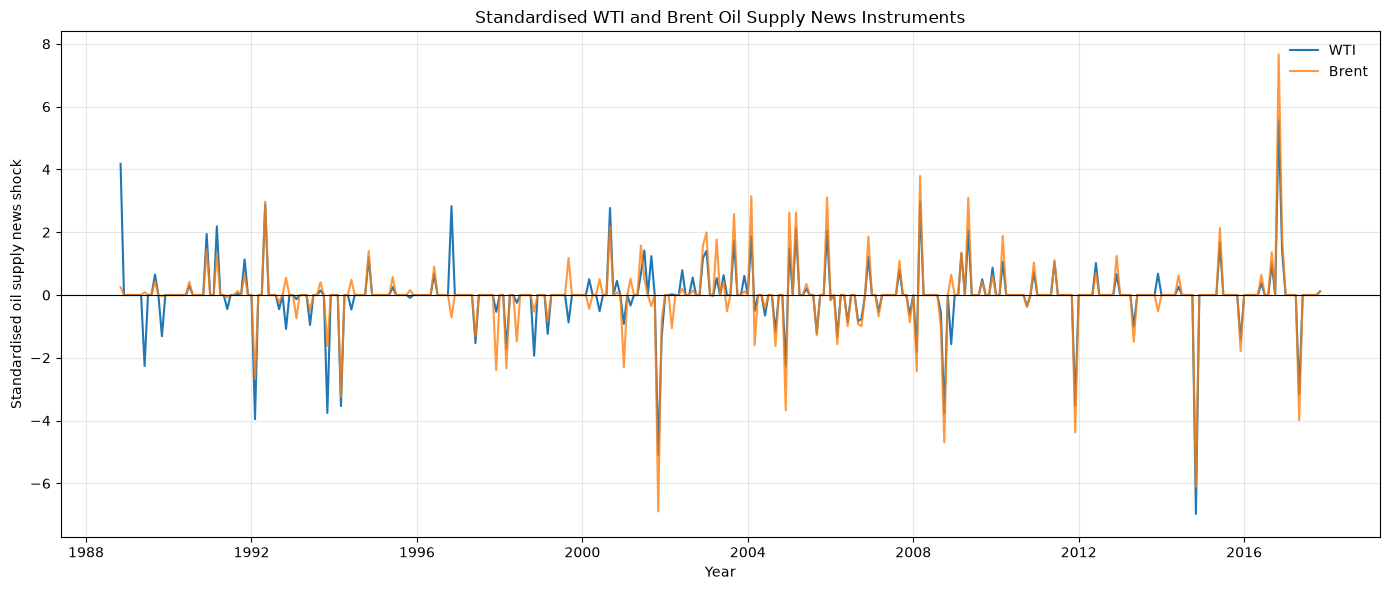

In [ ]:
# Plot the standardised WTI and Brent instruments
# over the common informative comparison period

plot_data = (
    instrument_comparison
    .loc[
        (instrument_comparison["Month"] >= "1988-11")
        & (instrument_comparison["Month"] <= "2017-11")
    ]
    .copy()
)

plot_data["Date"] = (
    plot_data["Month"]
    .dt.to_timestamp()
)

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    plot_data["Date"],
    plot_data["WTI_Shock_Standardised"],
    label="WTI",
    linewidth=1.5,
)

ax.plot(
    plot_data["Date"],
    plot_data["Brent_Shock_Standardised"],
    label="Brent",
    linewidth=1.5,
    alpha=0.8,
)

ax.axhline(
    y=0,
    color="black",
    linewidth=0.8,
)

#ax.set_title(
#    "Standardised WTI and Brent Oil Supply News Instruments"
#)

ax.set_xlabel("Year")
ax.set_ylabel(
    "Standardised oil supply news shock"
)

ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "WTI_Brent_TS.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

**Figure 1.** Standardised monthly WTI and Brent oil supply news instruments over their common sample, November 1988 to November 2017.

**Interpretation:**  
Figure 1 shows that the replicated WTI and Brent oil supply news instruments exhibit similar dynamics over time. Most major positive and negative oil supply news shocks occur in the same months, indicating that both futures markets respond similarly to OPEC announcements. Their close co-movement observed is consistent with the common-sample correlation of 0.87, suggesting that both instruments capture a substantial common oil supply news component while retaining some benchmark-specific variation.

### **6.4. Comparison of Major Oil Supply News Shocks**

As a final comparison, the largest historical oil supply news shocks identified by the WTI and Brent instruments are examined.

Rather than comparing every monthly observation, this exercise ranks months according to the average absolute oil supply news shock across the two instruments. Focusing on the largest jointly important shocks highlights the episodes in which both benchmarks identify substantial oil supply news. If the two instruments measure the same underlying supply news, the largest historical shocks should occur in broadly the same months, even if their magnitudes differ somewhat across benchmarks.

In [31]:
# Compare the largest historical oil supply news shocks

largest_shocks = (
    instrument_comparison[
        [
            "Month",
            "WTI_Shock",
            "Brent_Shock",
        ]
    ]
    .copy()
)

# Compute the absolute shock in each series

largest_shocks["Absolute_WTI"] = (
    largest_shocks["WTI_Shock"].abs()
)

largest_shocks["Absolute_Brent"] = (
    largest_shocks["Brent_Shock"].abs()
)

# Rank months by the average absolute shock across the two benchmarks

largest_shocks["Average_Absolute_Shock"] = (
    largest_shocks[
        [
            "Absolute_WTI",
            "Absolute_Brent",
        ]
    ]
    .mean(axis=1)
)

largest_shocks = (
    largest_shocks
    .sort_values(
        "Average_Absolute_Shock",
        ascending=False,
    )
    .head(10)
    .drop(
        columns=[
            "Absolute_WTI",
            "Absolute_Brent",
            "Average_Absolute_Shock",
        ]
    )
)

print("Table 2. Largest Historical Oil Supply News Shocks")
display(
    largest_shocks.round(4)
)

Table 2. Largest Historical Oil Supply News Shocks


C:\Users\Yashna\AppData\Local\Temp\ipykernel_3456\1836102224.py:54: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  largest_shocks.round(4)


,Month,WTI_Shock,Brent_Shock
376,2014-11,-9.9005,-6.4452
400,2016-11,7.9056,8.0916
220,2001-11,-7.2324,-7.2776
303,2008-10,-5.3555,-4.9531
341,2011-12,-4.9944,-4.6184
37,1986-08,9.3830,0.0000
406,2017-05,-4.4919,-4.2089
128,1994-03,-5.0235,-3.4281
103,1992-02,-5.6142,-2.8206
296,2008-03,4.2200,4.0010


**Interpretation:**  
Table 2 shows that the WTI and Brent instruments rank many of the same months among their largest oil supply news shocks, including **November 2001**, **October 2008**, **November 2014**, and **November 2016**.

Although the magnitudes of individual shocks differ across the two benchmarks, their timing and direction are closely aligned. This event-based comparison complements the descriptive statistics, correlation analysis, and time-series evidence, providing further support that the WTI and Brent instruments capture a common underlying oil supply news factor.

## **7. Validation of the Proxy-SVAR: Replication of Känzig's U.S. Results**

Before applying the oil supply news instrument to Germany, we validate the Python implementation of the Proxy-SVAR by reproducing Känzig's baseline U.S. specification. This allows us to assess whether our implementation of the identification procedure is in line with that of Känzig and whether any subsequent differences in the German results can be attributed to differences in the underlying data and estimation sample.



### **7.1. Baseline Data and VAR Estimation**

The baseline data are taken directly from Känzig's replication package. The dataset contains the six variables used in the original monthly specification:

1. real oil price (`POIL`);
2. world oil production (`OILPROD`);
3. world oil inventories (`OILSTOCKS`);
4. world industrial production (`WORLDIP`);
5. U.S. industrial production (`IP`); and
6. U.S. consumer prices (`CPI`).

The variables are already transformed as in Känzig's replication files and are therefore not transformed again. The reduced-form VAR is estimated with 12 monthly lags and a constant, following the baseline specification in the original paper.

In [32]:
# Locate and load Känzig's baseline VAR dataset

from pathlib import Path
from scipy.io import loadmat

PROJECT_DIR = Path.cwd()

database_files = list(
    PROJECT_DIR.rglob("dataBaseM.mat")
)

if not database_files:
    raise FileNotFoundError(
        "dataBaseM.mat could not be found in the project directory."
    )

BASELINE_VAR_FILE = database_files[0]

us_baseline_mat = loadmat(
    BASELINE_VAR_FILE,
    squeeze_me=True,
)

print(
    "Loaded:",
    BASELINE_VAR_FILE
)

Loaded: c:\Users\Yashna\macro_II_project\Yashna's Code\Data for Replication\dataBaseM.mat


In [33]:
# Inspect the baseline dataset

print(
    "Data shape:",
    us_baseline_mat["data"].shape,
)

print(
    "Variable names:",
    us_baseline_mat["varNames"],
)

print(
    "Sample:",
    us_baseline_mat["sampleDates"][0],
    "to",
    us_baseline_mat["sampleDates"][-1],
)

Data shape: (528, 6)
Variable names: ['POIL' 'OILPROD' 'OILSTOCKS' 'WORLDIP' 'IP' 'CPI']
Sample: 1974M01 to 2017M12


In [34]:
# Construct Känzig's baseline U.S. dataset

us_var_names = (
    us_baseline_mat["varNames"]
    .tolist()
)

us_data = pd.DataFrame(
    us_baseline_mat["data"],
    columns=us_var_names,
)

# Convert MATLAB monthly date strings to pandas periods

us_date_strings = [
    str(date)
    for date in us_baseline_mat["sampleDates"]
]

us_data["date"] = pd.PeriodIndex(
    [
        date.replace("M", "-")
        for date in us_date_strings
    ],
    freq="M",
)

print(
    "Sample:",
    us_data["date"].min(),
    "to",
    us_data["date"].max(),
)

print(
    "Number of observations:",
    len(us_data),
)

display(
    us_data.head()
)

Sample: 1974-01 to 2017-12
Number of observations: 528


,POIL,OILPROD,OILSTOCKS,WORLDIP,IP,CPI,date
0,307.281202,1092.366972,627.749222,378.704351,385.244921,384.588320,1974-01
1,306.218492,1093.208859,631.571356,378.253622,384.936857,385.651030,1974-02
2,305.166958,1093.978108,631.260097,378.189405,384.957936,386.702564,1974-03
3,304.541304,1095.273451,634.354875,378.215302,384.652402,387.328218,1974-04
4,303.507169,1095.568934,637.887812,378.709292,385.407181,388.362353,1974-05


In [35]:
# Estimate Känzig's baseline VAR(12)

from statsmodels.tsa.api import VAR

us_var_columns = [
    "POIL",
    "OILPROD",
    "OILSTOCKS",
    "WORLDIP",
    "IP",
    "CPI",
]

us_var_data = (
    us_data[
        ["date"] + us_var_columns
    ]
    .dropna()
    .reset_index(drop=True)
)

us_var_model = VAR(
    us_var_data[us_var_columns]
)

us_var_res = us_var_model.fit(
    maxlags=12,
    trend="c",
)

print(
    "Number of VAR observations:",
    us_var_res.nobs,
)

print(
    "Number of lags:",
    us_var_res.k_ar,
)

print(
    "VAR stable:",
    us_var_res.is_stable(),
)

Number of VAR observations: 516
Number of lags: 12
VAR stable: True


**Note:** The baseline dataset spans **1974M1–2017M12**, providing 528 monthly observations. Estimating the VAR with 12 lags leaves 516 usable observations. The estimated VAR satisfies the stability condition, so the reduced-form dynamics can be used to construct impulse responses.

### **7.2. External-Instrument Identification**

The structural oil supply news shock is identified using Känzig's original monthly WTI oil supply news instrument.

The identification proceeds in three steps:

1. Load and align the WTI instrument with the reduced-form VAR residuals using the monthly date identifier.

2. Assess instrument relevance by regressing the reduced-form real-oil-price innovation on the external instrument.

3. Identify the structural impact vector from the covariance between the external instrument and the reduced-form VAR innovations. Following Känzig, the shock is normalised to generate a 10 percent increase in the real oil price on impact.

The resulting impact responses describe the contemporaneous effects of the identified oil supply news shock. The subsequent subsection propagates these responses through the VAR dynamics to obtain the full impulse-response functions.


In [36]:
# Load Känzig's original monthly WTI oil supply news instrument

wti_proxy_mat = loadmat(
    WTI_BENCHMARK_FILE,
    squeeze_me=True,
)

# MATLAB column 14 corresponds to Python index 13

us_wti_proxy = (
    wti_proxy_mat["oilProxiesWTIM"][:, 13]
)

us_wti_proxy_dates_raw = (
    wti_proxy_mat["sampleDatesProxy"]
)

# Convert MATLAB monthly dates to pandas periods

us_wti_proxy_dates = pd.PeriodIndex(
    [
        str(date).replace("M", "-")
        for date in us_wti_proxy_dates_raw
    ],
    freq="M",
)

us_wti_proxy_data = pd.DataFrame(
    {
        "date": us_wti_proxy_dates,
        "proxy": us_wti_proxy,
    }
)

print(
    "Proxy sample:",
    us_wti_proxy_data["date"].min(),
    "to",
    us_wti_proxy_data["date"].max(),
)

print(
    "Instrument observations:",
    len(us_wti_proxy_data),
)

display(
    us_wti_proxy_data.head()
)

Proxy sample: 1974-01 to 2017-12
Instrument observations: 528


,date,proxy
0,1974-01,0.0
1,1974-02,0.0
2,1974-03,0.0
3,1974-04,0.0
4,1974-05,0.0


In [37]:
# Align the WTI instrument with the reduced-form VAR residuals

us_residuals = (
    us_var_res.resid
    .copy()
)

us_residuals["date"] = (
    us_var_data.loc[
        us_residuals.index,
        "date",
    ]
    .values
)

us_proxy_sample = (
    us_residuals
    .merge(
        us_wti_proxy_data,
        on="date",
        how="inner",
    )
)

print(
    "Proxy-SVAR sample:",
    us_proxy_sample["date"].min(),
    "to",
    us_proxy_sample["date"].max(),
)

print(
    "Number of overlapping observations:",
    len(us_proxy_sample),
)

print(
    "Months with non-zero proxy:",
    (
        us_proxy_sample["proxy"] != 0
    ).sum(),
)

display(
    us_proxy_sample.head()
)

Proxy-SVAR sample: 1975-01 to 2017-12
Number of overlapping observations: 516
Months with non-zero proxy: 117


,POIL,OILPROD,OILSTOCKS,WORLDIP,IP,CPI,date,proxy
0,1.426302,-3.525803,-0.922335,-0.396866,0.336660,0.178744,1975-01,0.0
1,6.536331,-1.893510,1.829397,0.416705,-0.450201,0.214155,1975-02,0.0
2,0.411759,-0.396614,-0.215717,0.570576,0.040397,0.005101,1975-03,0.0
3,-3.147683,-0.336008,-0.178307,0.338612,0.329177,-0.136102,1975-04,0.0
4,-3.374309,0.574813,-0.020295,-0.260600,-0.038104,-0.325712,1975-05,0.0


In [38]:
# Assess instrument relevance

first_stage_data = (
    us_proxy_sample[
        ["POIL", "proxy"]
    ]
    .copy()
)

X_first_stage = sm.add_constant(
    first_stage_data["proxy"]
)

# Standard OLS
first_stage_model = sm.OLS(
    first_stage_data["POIL"],
    X_first_stage,
).fit()

# Heteroskedasticity-robust OLS
first_stage_robust = sm.OLS(
    first_stage_data["POIL"],
    X_first_stage,
).fit(cov_type="HC1")

F_standard = first_stage_model.fvalue
F_robust = first_stage_robust.tvalues["proxy"] ** 2

print(
    f"First-stage coefficient: "
    f"{first_stage_robust.params['proxy']:.4f}"
)

print(
    f"Standard F-statistic:    "
    f"{F_standard:.2f}"
)

print(
    f"Robust F-statistic:      "
    f"{F_robust:.2f}"
)

print(
    f"R-squared:               "
    f"{first_stage_model.rsquared:.4f}"
)

First-stage coefficient: 1.0854
Standard F-statistic:    22.67
Robust F-statistic:      10.55
R-squared:               0.0422


In [39]:
# Identify the structural impact vector

proxy_values = (
    us_proxy_sample["proxy"]
    .astype(float)
    .values
)

cov_zu = []

for variable in us_var_columns:

    residual_values = (
        us_proxy_sample[variable]
        .astype(float)
        .values
    )

    covariance = np.cov(
        proxy_values,
        residual_values,
        ddof=0,
    )[0, 1]

    cov_zu.append(
        covariance
    )

cov_zu = np.array(
    cov_zu,
    dtype=float,
)

# Express responses relative to the oil-price innovation

relative_impact = (
    cov_zu
    / cov_zu[0]
)

# Normalise the shock to raise the real oil price by 10 percent on impact

impact_vector = (
    10.0
    * relative_impact
)

impact_table = pd.DataFrame(
    {
        "Variable": us_var_columns,
        "Impact Response": impact_vector,
    }
)

display(
    impact_table.round(4)
)

,Variable,Impact Response
0,POIL,10.0000
1,OILPROD,0.1243
2,OILSTOCKS,0.3231
3,WORLDIP,0.0029
4,IP,-0.1654
5,CPI,0.1391


**Interpretation:** The first-stage F-statistic is **22.67**, indicating that the WTI oil supply news instrument is relevant for the reduced-form innovation in the real oil price. 

The identified shock is normalised to increase the real oil price by 10 percent on impact. Oil inventories rise contemporaneously, while the immediate responses of world oil production and world industrial production are comparatively small. This pattern is consistent with the interpretation of the identified innovation as news about future oil supply rather than a contemporaneous supply disruption.

### **7.3. Replication of the Baseline Impulse Responses**

The identified structural impact vector is propagated through the estimated reduced-form VAR to obtain impulse responses over a 50-month horizon.

For each horizon $h$, the structural impulse response is given by

$$
IRF_h
=
\Psi_h b,
$$

where $\Psi_h$ denotes the moving-average coefficient matrix of the estimated VAR and $b$ is the identified structural impact vector.

The resulting impulse responses are then compared with Känzig's baseline findings.

In [40]:
# Compute impulse responses for Känzig's U.S. baseline

horizon = 50

# Reduced-form moving-average matrices
us_ma_matrices = (
    us_var_res.ma_rep(
        maxn=horizon
    )
)

# Structural impulse responses
us_irfs = np.array(
    [
        us_ma_matrices[h]
        @ impact_vector
        for h in range(horizon + 1)
    ]
)

us_irfs = pd.DataFrame(
    us_irfs,
    columns=us_var_columns,
)

us_irfs["Horizon"] = np.arange(
    horizon + 1
)

display(
    us_irfs.head()
)

,POIL,OILPROD,OILSTOCKS,WORLDIP,IP,CPI,Horizon
0,10.000000,0.124322,0.323105,0.002914,-0.165418,0.139057,0
1,12.294902,0.101825,0.243204,0.124593,-0.125221,0.305094,1
2,12.865453,0.187986,0.339811,0.157534,-0.105145,0.355242,2
3,12.123239,0.134212,0.403892,0.206581,-0.121680,0.364084,3
4,11.177663,0.013207,0.389202,0.225756,-0.126624,0.367080,4


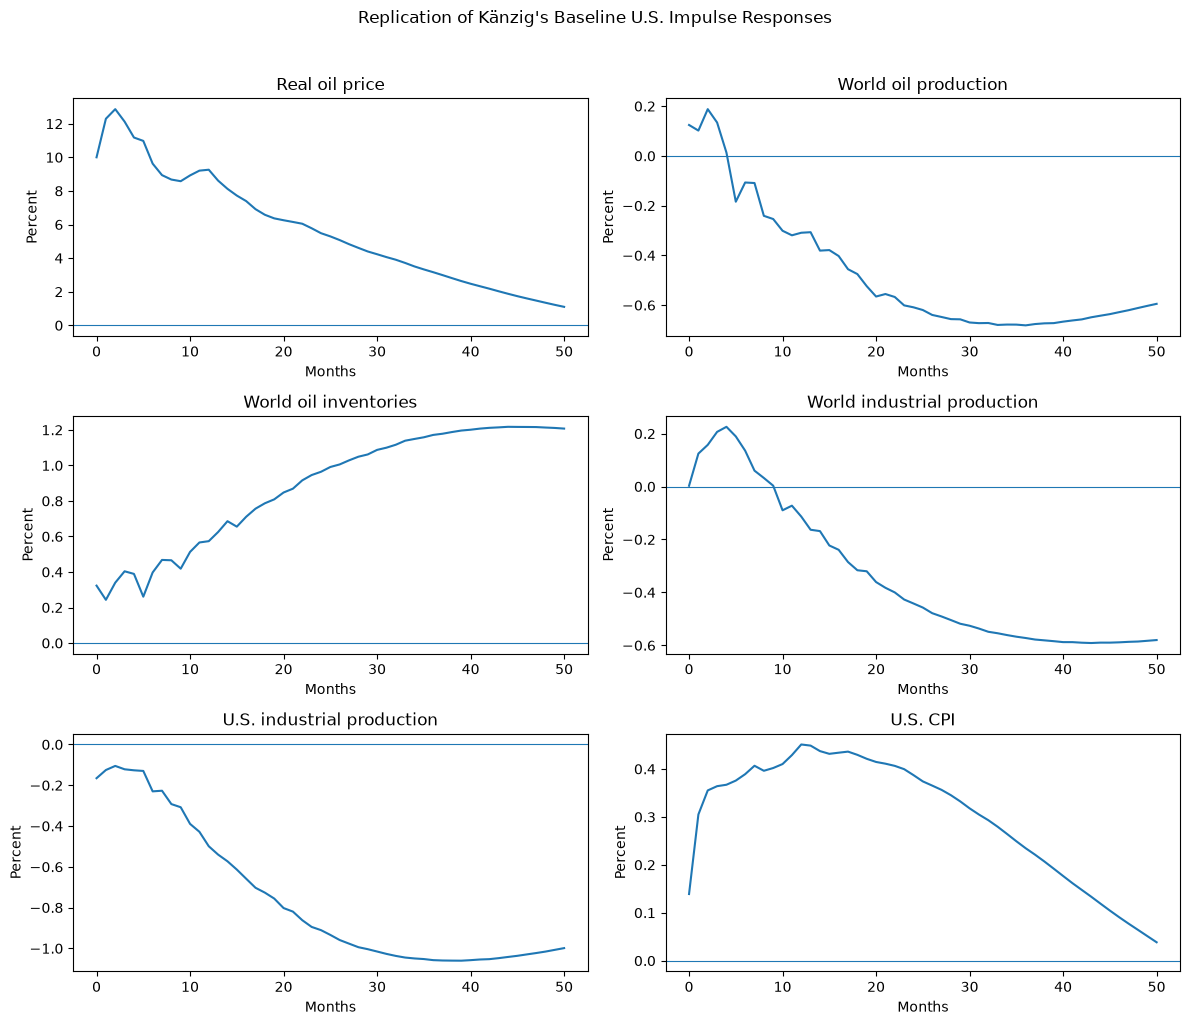

In [ ]:
# Plot Känzig's U.S. baseline impulse responses

variable_titles = {
    "POIL": "Real oil price",
    "OILPROD": "World oil production",
    "OILSTOCKS": "World oil inventories",
    "WORLDIP": "World industrial production",
    "IP": "U.S. industrial production",
    "CPI": "U.S. CPI",
}

fig, axes = plt.subplots(
    3,
    2,
    figsize=(12, 10),
)

axes = axes.flatten()

for ax, variable in zip(
    axes,
    us_var_columns,
):

    ax.plot(
        us_irfs["Horizon"],
        us_irfs[variable],
        linewidth=1.5,
    )

    ax.axhline(
        y=0,
        linewidth=0.8,
    )

    ax.set_title(
        variable_titles[variable]
    )

    ax.set_xlabel(
        "Months"
    )

    ax.set_ylabel(
        "Percent"
    )

#fig.suptitle(
#    "Replication of Känzig's Baseline U.S. Impulse Responses",
#    y=1.02,
#)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "us_irfs_full_sample.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:**  
The replicated impulse responses reproduce the main qualitative patterns documented by Känzig. Following an adverse oil supply news shock, the real oil price rises immediately and remains elevated. World oil production responds only gradually and subsequently declines, while oil inventories increase persistently.

World and U.S. industrial production fall with a delay, indicating a contraction in economic activity, while U.S. consumer prices rise. In particular, the delayed decline in oil production together with the accumulation of inventories is consistent with the interpretation of the identified innovation as news about future oil supply rather than an unexpected contemporaneous supply disruption.

This close correspondence with Känzig's baseline results validates the Python Proxy-SVAR implementation.

### **7.4. Sample-Period Diagnostic**

The German application considered below in our extension is constrained by the availability of the German variables and therefore uses a shorter estimation period beginning in 1991. Before attributing differences in the German impulse responses to country-specific transmission, this subsection examines whether shortening the estimation sample itself materially changes the estimated VAR dynamics.

To isolate the effect of the sample period, Känzig's original specification is re-estimated over **1991M1–2017M12**, matching the period used in the German application. 

The same external-instrument identification procedure is then repeated over the shorter sample, and the resulting impulse responses are compared with the full-sample U.S. baseline.

In [42]:
# Restrict Känzig's U.S. baseline data to the German sample period

us_short = (
    us_data[
        (us_data["date"] >= pd.Period("1991-01", freq="M"))
        & (us_data["date"] <= pd.Period("2017-12", freq="M"))
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Short sample:",
    us_short["date"].min(),
    "to",
    us_short["date"].max(),
)

print(
    "Number of observations:",
    len(us_short),
)

Short sample: 1991-01 to 2017-12
Number of observations: 324


In [43]:
# Estimate VAR(12) over the shorter sample

us_short_var = VAR(
    us_short[us_var_columns]
)

us_short_var_res = us_short_var.fit(
    maxlags=12,
    trend="c",
)

print(
    "Number of VAR observations:",
    us_short_var_res.nobs,
)

print(
    "Number of lags:",
    us_short_var_res.k_ar,
)

print(
    "VAR stable:",
    us_short_var_res.is_stable(),
)

Number of VAR observations: 312
Number of lags: 12
VAR stable: True


In [44]:
# Align the WTI proxy with short-sample VAR residuals

us_short_residuals = (
    us_short_var_res.resid
    .copy()
)

us_short_residuals["date"] = (
    us_short.loc[
        us_short_residuals.index,
        "date",
    ]
    .values
)

us_short_proxy_sample = (
    us_short_residuals
    .merge(
        us_wti_proxy_data,
        on="date",
        how="inner",
    )
)

print(
    "Short Proxy-SVAR sample:",
    us_short_proxy_sample["date"].min(),
    "to",
    us_short_proxy_sample["date"].max(),
)

print(
    "Number of overlapping observations:",
    len(us_short_proxy_sample),
)

print(
    "Months with non-zero proxy:",
    (
        us_short_proxy_sample["proxy"] != 0
    ).sum(),
)

Short Proxy-SVAR sample: 1992-01 to 2017-12
Number of overlapping observations: 312
Months with non-zero proxy: 91


In [45]:
# Assess instrument relevance over the shorter sample

X_short_first_stage = sm.add_constant(
    us_short_proxy_sample["proxy"]
)

short_first_stage_model = sm.OLS(
    us_short_proxy_sample["POIL"],
    X_short_first_stage,
).fit()

short_first_stage_robust = sm.OLS(
    us_short_proxy_sample["POIL"],
    X_short_first_stage,
).fit(cov_type="HC1")

F_standard = short_first_stage_model.fvalue
F_robust = short_first_stage_robust.tvalues["proxy"] ** 2

print(
    f"First-stage coefficient: "
    f"{short_first_stage_robust.params['proxy']:.4f}"
)

print(
    f"Standard F-statistic:    "
    f"{F_standard:.2f}"
)

print(
    f"Robust F-statistic:      "
    f"{F_robust:.2f}"
)

print(
    f"R-squared:               "
    f"{short_first_stage_model.rsquared:.4f}"
)

First-stage coefficient: 0.9152
Standard F-statistic:    13.62
Robust F-statistic:      8.42
R-squared:               0.0421


In [46]:
# Identify the short-sample structural impact vector

short_proxy_values = (
    us_short_proxy_sample["proxy"]
    .astype(float)
    .values
)

short_cov_zu = []

for variable in us_var_columns:

    residual_values = (
        us_short_proxy_sample[variable]
        .astype(float)
        .values
    )

    covariance = np.cov(
        short_proxy_values,
        residual_values,
        ddof=0,
    )[0, 1]

    short_cov_zu.append(
        covariance
    )

short_cov_zu = np.array(
    short_cov_zu,
    dtype=float,
)

short_relative_impact = (
    short_cov_zu
    / short_cov_zu[0]
)

short_impact_vector = (
    10.0
    * short_relative_impact
)

short_impact_table = pd.DataFrame(
    {
        "Variable": us_var_columns,
        "Impact Response": short_impact_vector,
    }
)

display(
    short_impact_table.round(4)
)

,Variable,Impact Response
0,POIL,10.0000
1,OILPROD,-0.0332
2,OILSTOCKS,0.3739
3,WORLDIP,0.1791
4,IP,0.0328
5,CPI,0.1507


In [47]:
# Compute U.S. IRFs using the 1991–2017 estimation sample

horizon = 50

# Moving-average representation of the short-sample VAR
us_short_ma_matrices = (
    us_short_var_res.ma_rep(
        maxn=horizon
    )
)

# Structural impulse responses
us_short_irfs = np.array(
    [
        us_short_ma_matrices[h]
        @ short_impact_vector
        for h in range(horizon + 1)
    ]
)

# Store impulse responses in a DataFrame
us_short_irfs = pd.DataFrame(
    us_short_irfs,
    columns=us_var_columns,
)

us_short_irfs["Horizon"] = np.arange(
    horizon + 1
)

display(
    us_short_irfs.head()
)

,POIL,OILPROD,OILSTOCKS,WORLDIP,IP,CPI,Horizon
0,10.000000,-0.033240,0.373856,0.179115,0.032758,0.150733,0
1,10.562403,0.024076,0.240177,0.312478,0.070316,0.296495,1
2,11.399179,0.149470,0.285516,0.378978,0.106222,0.315343,2
3,9.836666,0.126988,0.277552,0.458916,0.146405,0.319424,3
4,8.274742,0.198514,0.226061,0.469286,0.171345,0.283703,4


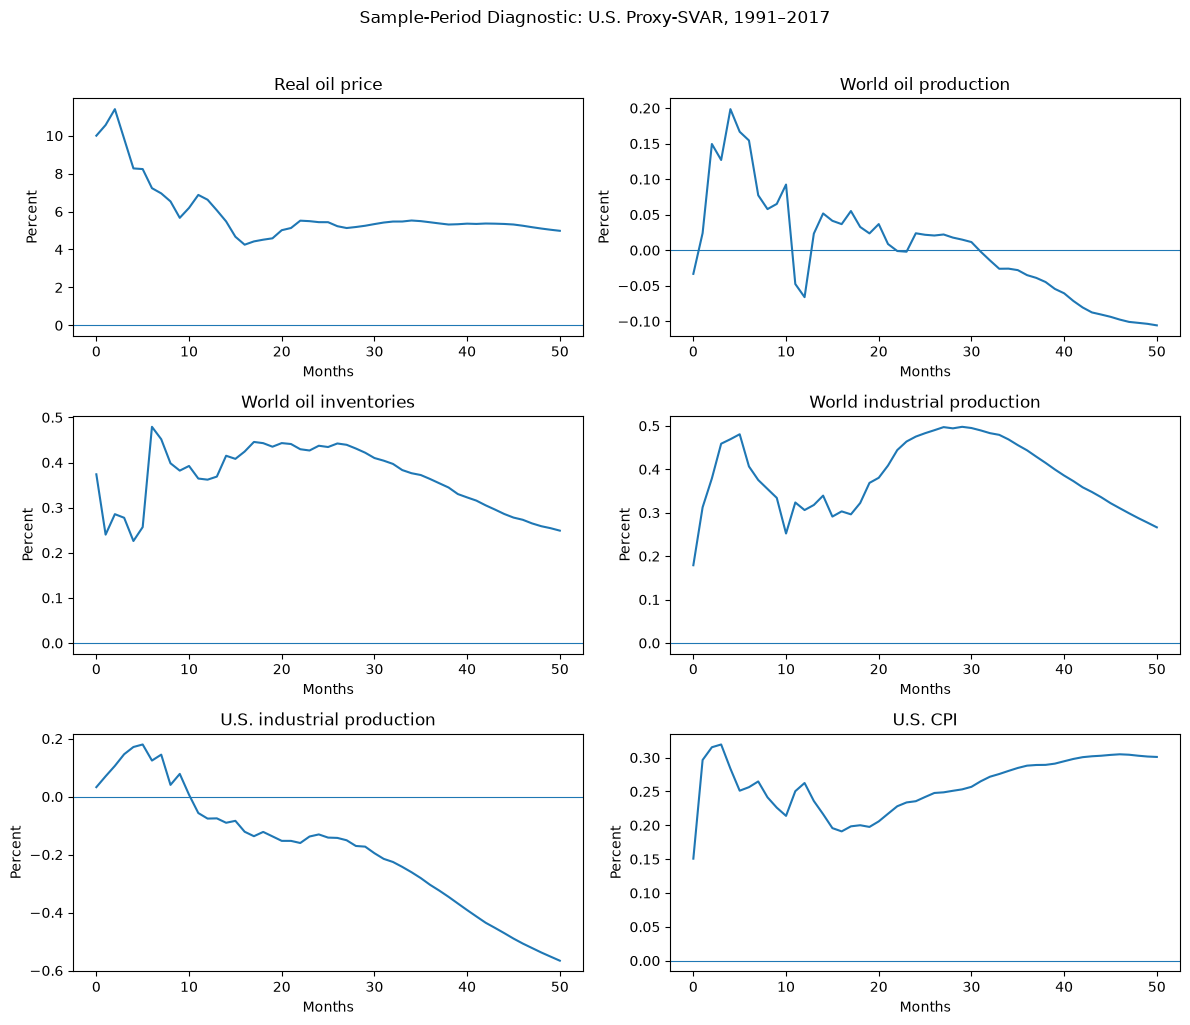

In [ ]:
# Plot short-sample U.S. impulse responses

fig, axes = plt.subplots(
    3,
    2,
    figsize=(12, 10),
)

axes = axes.flatten()

for ax, variable in zip(
    axes,
    us_var_columns,
):

    ax.plot(
        us_short_irfs["Horizon"],
        us_short_irfs[variable],
        linewidth=1.5,
    )

    ax.axhline(
        y=0,
        linewidth=0.8,
    )

    ax.set_title(
        variable_titles[variable]
    )

    ax.set_xlabel("Months")
    ax.set_ylabel("Percent")

#fig.suptitle(
#    "Sample-Period Diagnostic: U.S. Proxy-SVAR, 1991–2017",
#    y=1.02,
#)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "us_irfs_short_sample.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:**  
Restricting the estimation sample to **1991M1–2017M12** changes the estimated impulse responses even though the specification remains the same. 

The first-stage F-statistic declines from **22.67** in the full sample to **13.62** in the shorter sample, although the instrument remains relevant. World industrial production now rises rather than falls following the shock, the decline in world oil production becomes weaker and more delayed, the inventory response is smaller, and the consumer-price response becomes substantially more persistent.

Thus, the estimated propagation of the oil supply news shock is sensitive to the shorter estimation period.

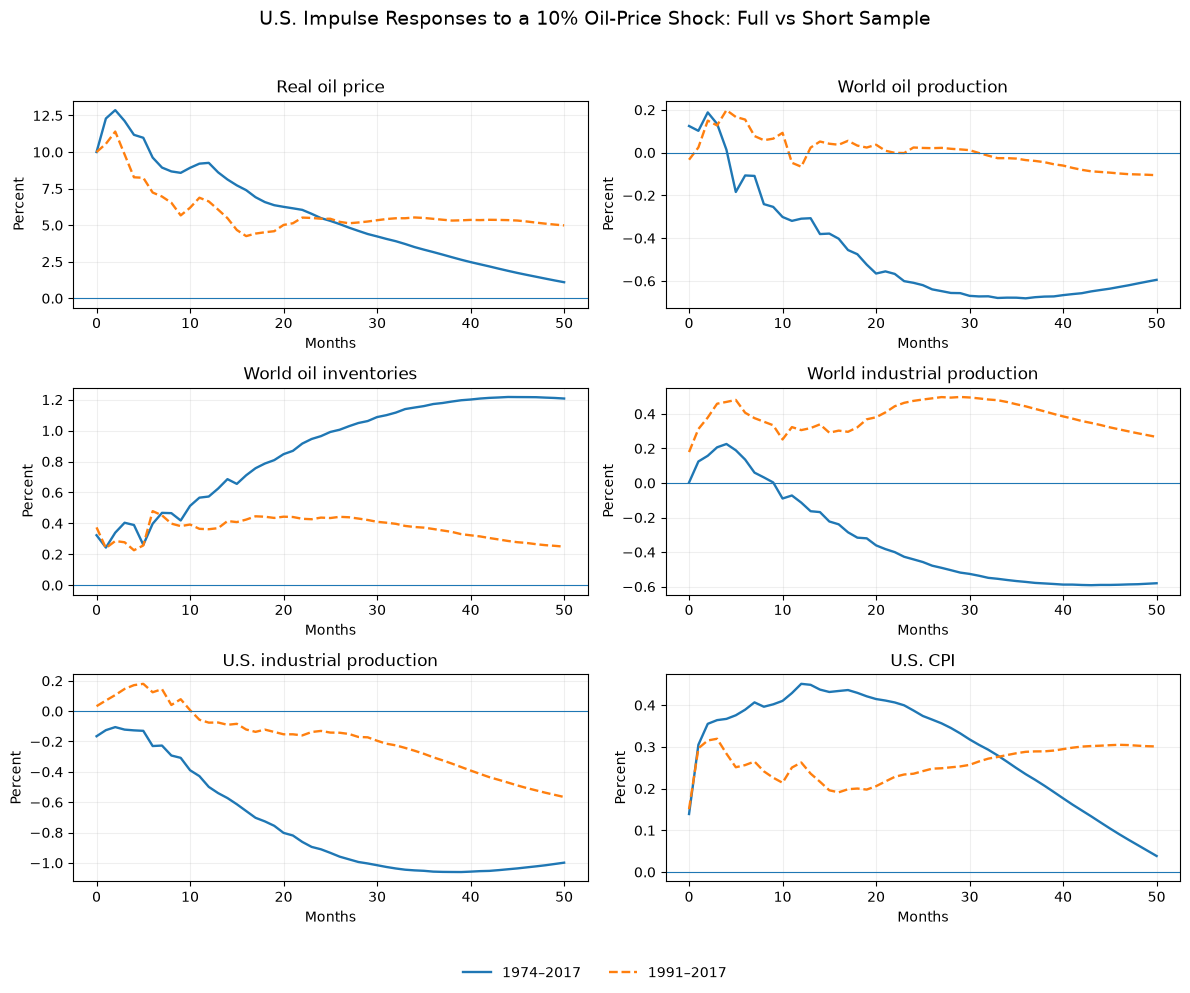

In [ ]:
# ============================================================
# Compare full-sample and short-sample U.S. impulse responses
# ============================================================

import matplotlib.pyplot as plt

variable_titles = {
    "POIL": "Real oil price",
    "OILPROD": "World oil production",
    "OILSTOCKS": "World oil inventories",
    "WORLDIP": "World industrial production",
    "IP": "U.S. industrial production",
    "CPI": "U.S. CPI",
}

fig, axes = plt.subplots(
    3,
    2,
    figsize=(12, 10),
)

axes = axes.flatten()

for ax, variable in zip(
    axes,
    us_var_columns,
):

    # Full sample: 1974–2017
    ax.plot(
        us_irfs["Horizon"],
        us_irfs[variable],
        linewidth=1.7,
        label="1974–2017",
    )

    # Short sample: 1991–2017
    ax.plot(
        us_short_irfs["Horizon"],
        us_short_irfs[variable],
        linewidth=1.7,
        linestyle="--",
        label="1991–2017",
    )

    ax.axhline(
        y=0,
        linewidth=0.8,
    )

    ax.set_title(
        variable_titles[variable]
    )

    ax.set_xlabel("Months")
    ax.set_ylabel("Percent")

    ax.grid(
        alpha=0.2
    )

# Common legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
)

#fig.suptitle(
#    "U.S. Impulse Responses to a 10% Oil-Price Shock: Full vs Short Sample",
#    fontsize=14,
#)

fig.tight_layout(
    rect=[0, 0.05, 1, 0.96]
)

fig.savefig(
    OUTPUT_DIR / "us_irfs_full_vs_short_sample.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---
---

# **Extending Känzig (2021): Proxy SVAR Analysis Using the Brent Oil Supply News Instrument**

The previous sections demonstrated that the Python implementation successfully reproduces Känzig's published WTI and Brent oil supply news instruments and that the two benchmarks exhibit similar statistical properties and historical dynamics. 

This section extends Känzig's baseline Proxy SVAR to Germany. The identification strategy is kept unchanged: unexpected movements in Brent futures prices around OPEC announcements serve as an external instrument for the structural oil supply news shock.

The German application proceeds in three steps:

1. construct a six-variable German baseline VAR by replacing U.S. industrial production and CPI with their German counterparts;
2. identify the oil supply news shock using the monthly Brent instrument;
3. augment the baseline model one variable at a time with German import prices and producer prices to study transmission through the pricing chain.

The estimation sample is **1991M01–2017M12**, reflecting the availability of monthly data for unified Germany.


## **1. Prepare German Macroeconomic Data**

We first load German industrial production, consumer prices, producer prices, and import prices. All series are monthly. The price and production indices will later be transformed as \(100\log(x_t)\), consistent with Känzig's treatment of index variables.

### **1.1 German industrial production**

The Bundesbank file contains metadata in the first rows. We keep only observations with a valid monthly date (`YYYY-MM`) and the corresponding seasonally adjusted production index.

In [50]:
bbk_raw = pd.read_csv(
    DATA_DIR_G / "bbk.csv",
    skiprows=10,
    header=None,
    names=["date", "ip_de", "flags"],
    engine="python"
)

bbk = bbk_raw.loc[
    bbk_raw["date"].astype(str).str.match(r"^\d{4}-\d{2}$"),
    ["date", "ip_de"]
].copy()

bbk["date"] = pd.to_datetime(bbk["date"], format="%Y-%m")
bbk["ip_de"] = pd.to_numeric(bbk["ip_de"], errors="coerce")
bbk = bbk.dropna().reset_index(drop=True)

bbk.head()

,date,ip_de
0,1991-01-01,81.5
1,1991-02-01,79.8
2,1991-03-01,79.8
3,1991-04-01,79.1
4,1991-05-01,78.2


### **1.2 German CPI, PPI, and import prices**

The three Destatis files have the same structure: year, month name, index value, followed by additional growth-rate columns. The helper below extracts only the monthly index level.


In [51]:
MONTHS = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
}

def load_destatis(filepath, variable_name):
    # Load a monthly Destatis index and return date + index level.
    raw = pd.read_csv(
        filepath,
        sep=";",
        skiprows=6,
        header=None,
        engine="python"
    )

    raw = raw.iloc[:, :3]
    raw.columns = ["year", "month", variable_name]

    # Keep only rows containing actual yearly observations.
    raw = raw[
        raw["year"].astype(str).str.fullmatch(r"\d{4}")
    ].copy()

    raw["month"] = raw["month"].map(MONTHS)

    raw["date"] = pd.to_datetime(
        dict(
            year=raw["year"].astype(int),
            month=raw["month"],
            day=1
        )
    )

    raw[variable_name] = pd.to_numeric(
        raw[variable_name],
        errors="coerce"
    )

    return (
        raw[["date", variable_name]]
        .dropna()
        .reset_index(drop=True)
    )

In [52]:
cpi = load_destatis(
    DATA_DIR_G / "61111-0002_en.csv",
    "cpi_de"
)

ppi = load_destatis(
    DATA_DIR_G / "61241-0002_en.csv",
    "ppi_de"
)

import_prices = load_destatis(
    DATA_DIR_G / "61411-0002_en.csv",
    "import_price_de"
)

display(cpi.head())
display(ppi.head())
display(import_prices.head())

,date,cpi_de
0,1991-01-01,60.5
1,1991-02-01,60.8
2,1991-03-01,60.8
3,1991-04-01,61.0
4,1991-05-01,61.1


,date,ppi_de
0,1976-01-01,43.9
1,1976-02-01,44.1
2,1976-03-01,44.3
3,1976-04-01,44.6
4,1976-05-01,44.7


,date,import_price_de
0,1962-01-01,38.0
1,1962-02-01,38.2
2,1962-03-01,38.5
3,1962-04-01,38.7
4,1962-05-01,38.3


### **1.3 Merge German series and restrict the sample**

All German series are merged by month and converted to a monthly `Period` index. We restrict the data to 1991M01–2017M12 before combining them with Känzig's global oil-market variables.


In [53]:
germany = (
    bbk
    .merge(cpi, on="date", how="inner")
    .merge(ppi, on="date", how="inner")
    .merge(import_prices, on="date", how="inner")
)

germany["date"] = pd.to_datetime(germany["date"]).dt.to_period("M")

start = pd.Period("1991-01", freq="M")
end = pd.Period("2017-12", freq="M")

germany = (
    germany.loc[germany["date"].between(start, end)]
    .sort_values("date")
    .reset_index(drop=True)
)

print("German sample:", germany["date"].min(), "-", germany["date"].max())
print("Observations:", len(germany))
display(germany.head())


German sample: 1991-01 - 2017-12
Observations: 324


,date,ip_de,cpi_de,ppi_de,import_price_de
0,1991-01,81.5,60.5,65.7,78.9
1,1991-02,79.8,60.8,65.7,78.3
2,1991-03,79.8,60.8,65.6,78.6
3,1991-04,79.1,61.0,66.2,79.5
4,1991-05,78.2,61.1,66.2,79.4


## **2. Add Känzig's Global Oil-Market Variables**

Känzig's transformed monthly VAR data contain six variables:
`POIL`, `OILPROD`, `OILSTOCKS`, `WORLDIP`, `IP`, and `CPI`.

For the German extension we retain the first four global/oil-market variables and replace U.S. industrial production and CPI with German series.

Because the extension uses the **Brent specification**, we load Känzig's Brent version of the monthly VAR data. The fallback path below accommodates either common folder layout.


In [54]:
# Locate Känzig's Brent-based monthly VAR dataset.
BRENT_VAR_DATA_FILE = DATA_DIR / "dataBrentM.mat"

db = loadmat(BRENT_VAR_DATA_FILE)

var_names = [
    np.asarray(x).squeeze().item()
    for x in db["varNames"].ravel()
]

date_strings = [
    np.asarray(x).squeeze().item()
    for x in db["sampleDates"].ravel()
]

dates = (
    pd.to_datetime(date_strings, format="%YM%m")
    .to_period("M")
)

kaenzig = pd.DataFrame(
    db["data"],
    columns=var_names
)

kaenzig.insert(0, "date", dates)

print("Variables:", var_names)
display(kaenzig.head())


Variables: ['POIL', 'OILPROD', 'OILSTOCKS', 'WORLDIP', 'IP', 'CPI']


,date,POIL,OILPROD,OILSTOCKS,WORLDIP,IP,CPI
0,1974-01,-132.418844,1092.366972,627.749222,378.704351,385.244921,384.588320
1,1974-02,-133.481553,1093.208859,631.571356,378.253622,384.936857,385.651030
2,1974-03,-134.533088,1093.978108,631.260097,378.189405,384.957936,386.702564
3,1974-04,-135.158742,1095.273451,634.354875,378.215302,384.652402,387.328218
4,1974-05,-136.192877,1095.568934,637.887812,378.709292,385.407181,388.362353


In [55]:
# Keep the common German sample and the four global/oil-market variables.
kaenzig_de = (
    kaenzig.loc[
        kaenzig["date"].between(start, end),
        ["date", "POIL", "OILPROD", "OILSTOCKS", "WORLDIP"]
    ]
    .rename(columns={
        "POIL": "world_oil_price",
        "OILPROD": "world_prod",
        "OILSTOCKS": "world_inv",
        "WORLDIP": "world_ip"
    })
    .reset_index(drop=True)
)


## **3. Construct the German Estimation Dataset**

The German variables are transformed as $100\log(x_t)$, matching Känzig's transformation of production and price indices. The four variables imported from `dataBrentM.mat` are already transformed and therefore must **not** be logged again.

The resulting dataset contains the six-variable German baseline plus the two pricing-chain variables used later for augmented models.


In [56]:
data_germany = (
    kaenzig_de
    .merge(
        germany[
            ["date", "ip_de", "import_price_de", "ppi_de", "cpi_de"]
        ],
        on="date",
        how="inner",
        validate="one_to_one"
    )
    .sort_values("date")
    .reset_index(drop=True)
)

# Match Känzig's transformation of index variables.
for col in ["ip_de", "import_price_de", "ppi_de", "cpi_de"]:
    data_germany[col] = 100 * np.log(data_germany[col])

data_germany = data_germany[
    [
        "date",
        "world_oil_price",
        "world_prod",
        "world_inv",
        "world_ip",
        "ip_de",
        "import_price_de",
        "ppi_de",
        "cpi_de"
    ]
]

print("Shape:", data_germany.shape)
print("Sample:", data_germany["date"].min(), "-", data_germany["date"].max())
print("\nMissing values:")
print(data_germany.isna().sum())

display(data_germany.head())


Shape: (324, 9)
Sample: 1991-01 - 2017-12

Missing values:
date               0
world_oil_price    0
world_prod         0
world_inv          0
world_ip           0
ip_de              0
import_price_de    0
ppi_de             0
cpi_de             0
dtype: int64


,date,world_oil_price,world_prod,world_inv,world_ip,ip_de,import_price_de,ppi_de,cpi_de
0,1991-01,-174.307537,1101.366207,764.320070,414.992085,440.060302,436.818123,418.509893,410.264337
1,1991-02,-193.132855,1100.852532,764.588938,414.287644,437.952350,436.054760,418.509893,410.758979
2,1991-03,-195.515153,1101.274531,765.866869,413.889416,437.952350,436.437170,418.357570,410.758979
3,1991-04,-195.214718,1098.939244,763.551382,414.613641,437.071287,437.575702,419.268046,411.087386
4,1991-05,-195.532007,1098.639787,763.210313,415.064219,435.926965,437.449837,419.268046,411.251187


### **3.1 Visual inspection**

The plots provide a simple check for discontinuities, missing segments, or implausible values before estimation. Dates are converted to timestamps only for plotting so that Matplotlib displays a readable yearly axis.


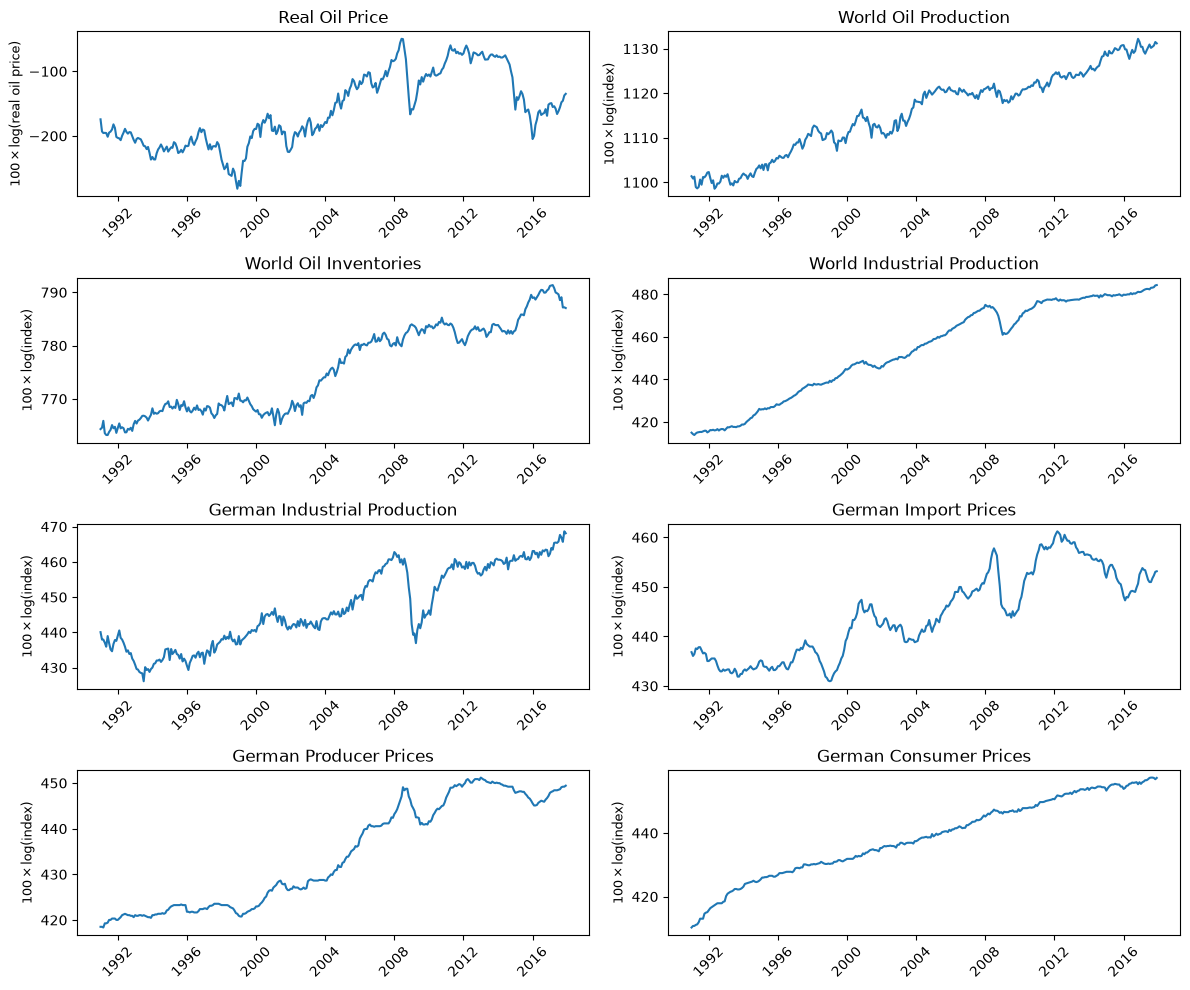

In [57]:
plot_dates = data_germany["date"].dt.to_timestamp()

plot_cols = [
    "world_oil_price",
    "world_prod",
    "world_inv",
    "world_ip",
    "ip_de",
    "import_price_de",
    "ppi_de",
    "cpi_de"
]

plot_titles = {
    "world_oil_price": "Real Oil Price",
    "world_prod": "World Oil Production",
    "world_inv": "World Oil Inventories",
    "world_ip": "World Industrial Production",
    "ip_de": "German Industrial Production",
    "import_price_de": "German Import Prices",
    "ppi_de": "German Producer Prices",
    "cpi_de": "German Consumer Prices"
}

plot_labels = {
    "world_oil_price": r"$100 \times \log(\mathrm{real\ oil\ price})$",
    "world_prod": r"$100 \times \log(\mathrm{index})$",
    "world_inv": r"$100 \times \log(\mathrm{index})$",
    "world_ip": r"$100 \times \log(\mathrm{index})$",
    "ip_de": r"$100 \times \log(\mathrm{index})$",
    "import_price_de": r"$100 \times \log(\mathrm{index})$",
    "ppi_de": r"$100 \times \log(\mathrm{index})$",
    "cpi_de": r"$100 \times \log(\mathrm{index})$"
}

fig, axes = plt.subplots(4, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    ax.plot(plot_dates, data_germany[col])
    ax.set_title(plot_titles[col])
    ax.set_ylabel(plot_labels[col], fontsize=9)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "german_data_timeseries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
# ============================================================
# Plot variables used in the German extension
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plot_dates = data_germany["date"].dt.to_timestamp()

plot_cols = [
    "world_oil_price",
    "world_prod",
    "world_inv",
    "world_ip",
    "ip_de",
    "import_price_de",
    "ppi_de",
    "cpi_de",
]

variable_titles = {
    "world_oil_price": "Real oil price",
    "world_prod": "World oil production",
    "world_inv": "World oil inventories",
    "world_ip": "World industrial production",
    "ip_de": "German industrial production",
    "import_price_de": "German import prices",
    "ppi_de": "German producer prices",
    "cpi_de": "German consumer prices",
}

plot_labels = {
    "world_oil_price": r"$100 \times \log(\mathrm{real\ oil\ price})$",
    "world_prod": r"$100 \times \log(\mathrm{index})$",
    "world_inv": r"$100 \times \log(\mathrm{index})$",
    "world_ip": r"$100 \times \log(\mathrm{index})$",
    "ip_de": r"$100 \times \log(\mathrm{index})$",
    "import_price_de": r"$100 \times \log(\mathrm{index})$",
    "ppi_de": r"$100 \times \log(\mathrm{index})$",
    "cpi_de": r"$100 \times \log(\mathrm{index})$",
}

fig, axes = plt.subplots(
    4,
    2,
    figsize=(12, 10),
)

axes = axes.flatten()

for ax, variable in zip(
    axes,
    plot_cols,
):

    ax.plot(
        plot_dates,
        data_germany[variable],
        linewidth=1.7,
    )

    ax.set_title(
        variable_titles[variable]
    )

    ax.set_xlabel("Year")

    ax.grid(
        alpha=0.2
    )

    ax.xaxis.set_major_locator(
        mdates.YearLocator(5)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y")
    )

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "german_data_timeseries.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

#\caption*{\footnotesize
#Notes: The figure shows the monthly variables used in the German extension
#over 1991--2017. Variables are displayed in the transformations used for the
#VAR estimation. Index variables are expressed as $100\log(x_t)$.
#}

In [58]:
# Optional: save the cleaned monthly dataset for the estimation section.
data_germany.to_csv(
    DATA_DIR_G / "germany_proxy_svar_data.csv",
    index=False
)

## **4. Define the Baseline and Extension Specifications**

Following Känzig's extended-VAR strategy, the six-variable baseline is kept fixed. Import prices and producer prices are then appended **one at a time** rather than estimating one large system.

**Baseline variables**
- Real oil price
- World oil production
- World oil inventories
- World industrial production
- German industrial production
- German CPI

Extensions:
- baseline + German import prices;
- baseline + German producer prices.


In [306]:
baseline_cols = [
    "world_oil_price",
    "world_prod",
    "world_inv",
    "world_ip",
    "ip_de",
    "cpi_de"
]

extension_cols = [
    "import_price_de",
    "ppi_de"
]

baseline_de = data_germany[["date"] + baseline_cols].copy()
ext_de = data_germany[["date"] + extension_cols].copy()


## **5. Estimate the Reduced-Form Baseline VAR**

Känzig's monthly baseline uses 12 lags and a constant. Estimating the reduced-form VAR yields the innovations $u_t$, which are subsequently linked to the structural oil supply news shock through the external instrument.


In [307]:
from statsmodels.tsa.api import VAR

Y = baseline_de[baseline_cols]

var_model = VAR(Y)
var_res = var_model.fit(
    maxlags=12,
    trend="c"
)

print(var_res.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 02, Sep, 2026
Time:                     12:59:20
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    5.28367
Nobs:                     312.000    HQIC:                   2.12917
Log likelihood:          -2222.79    FPE:                    1.08552
AIC:                    0.0290694    Det(Omega_mle):        0.307468
--------------------------------------------------------------------
Results for equation world_oil_price
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const                     636.915430       335.064069            1.901           0.057
L1.world_oil_price          1.051263         0.067659           15.538           0.000
L1.world_prod             

In [308]:
# Reduced-form residuals. Twelve lags imply that the residual sample begins
# twelve months after the start of the estimation sample.
u = var_res.resid.copy()
u["date"] = baseline_de.loc[u.index, "date"].values

print("Residual sample:", u["date"].min(), "-", u["date"].max())
display(u.head())


Residual sample: 1992-01 - 2017-12


,world_oil_price,world_prod,world_inv,world_ip,ip_de,cpi_de,date
12,-2.976513,0.719378,0.256491,0.054420,2.487444,0.235011,1992-01
13,2.964402,-0.197473,0.611047,0.633836,2.600857,0.073743,1992-02
14,-4.449745,-0.426265,-0.411872,0.070216,0.243963,-0.088332,1992-03
15,2.519684,1.160285,-0.151760,0.046169,-0.815401,-0.115792,1992-04
16,2.914775,-1.086168,-0.184018,0.153950,-0.082439,0.010882,1992-05


## **6. Prepare the Constructed Brent Instrument**

The monthly Brent proxy is taken directly from previousely constructed dataset in the replication part. In months without an OPEC announcement the instrument equals zero. The benchmark composite corresponds to MATLAB `ncontract = 14`, i.e. Python column index `13`.

In [309]:
# to use Kanzig proxy
# brent_mat = loadmat(BRENT_BENCHMARK_FILE)

# brent_monthly = brent_mat["oilProxiesBrentM"]

# proxy_date_strings = [
#    np.asarray(x).squeeze().item()
#    for x in brent_mat["sampleDatesProxy"].ravel()
#]

#proxy_dates = (
#    pd.to_datetime(proxy_date_strings, format="%YM%m")
#    .to_period("M")
#)

# MATLAB ncontract = 14 -> Python column index 13.
#brent_proxy = pd.DataFrame({
#    "date": proxy_dates,
#    "proxy": brent_monthly[:, 13].squeeze()
#})

#print("Proxy sample:", brent_proxy["date"].min(), "-", brent_proxy["date"].max())
#print("Non-zero proxy months:", (brent_proxy["proxy"] != 0).sum())
#display(brent_proxy.loc[brent_proxy["proxy"] != 0].head())

In [310]:
brent_proxy_rep = (
    brent_monthly_shocks
    .rename(
        columns={
            "Month": "date",
            "OilSupplyNews": "proxy"
        }
    )
    [["date", "proxy"]]
    .copy()
)

In [311]:
display(brent_proxy_rep.head())

,date,proxy
0,1988-11,1.066986
1,1988-12,0.000000
2,1989-01,0.000000
3,1989-02,0.000000
4,1989-03,0.000000


### **6.1 Align the proxy with the VAR innovations**

Proxy-SVAR identification uses the covariance between the instrument and the reduced-form innovations. We therefore merge the monthly proxy with the VAR residual sample by date. Zero-valued non-announcement months are retained.


In [312]:
proxy_sample = (
    u
    .merge(
        brent_proxy_rep[["date", "proxy"]],
        on="date",
        how="inner"
    )
    .dropna()
    .reset_index(drop=True)
)

print("Identification sample:",
      proxy_sample["date"].min(), "-", proxy_sample["date"].max())
print("N =", len(proxy_sample))
print("Non-zero proxy months =", (proxy_sample["proxy"] != 0).sum())


Identification sample: 1992-01 - 2017-11
N = 311
Non-zero proxy months = 91


## **7. Test Instrument Relevance**

The first-stage regression relates the reduced-form oil-price innovation to the Brent surprise.

We report both the conventional and heteroskedasticity-robust first-stage statistics.


In [313]:
import statsmodels.api as sm

X = sm.add_constant(proxy_sample["proxy"])

first_stage = sm.OLS(
    proxy_sample["world_oil_price"],
    X
).fit()

first_stage_robust = sm.OLS(
    proxy_sample["world_oil_price"],
    X
).fit(cov_type="HC1")

F_standard = first_stage.fvalue
F_robust = first_stage_robust.tvalues["proxy"] ** 2

print(f"First-stage coefficient: {first_stage_robust.params['proxy']:.4f}")
print(f"Standard F-statistic:    {F_standard:.2f}")
print(f"Robust F-statistic:      {F_robust:.2f}")
print(f"R-squared:               {first_stage.rsquared:.4f}")


First-stage coefficient: 0.2849
Standard F-statistic:    9.13
Robust F-statistic:      6.45
R-squared:               0.0287


## **8. Identify the Structural Impact Vector**

With a valid external instrument $begin:math:text$z\_t$end:math:text$, the relative contemporaneous effects of the oil supply news shock are identified from

$$
\frac{s_{j1}}{s_{11}}
=
\frac{\operatorname{Cov}(z_t,\,u_{jt})}
     {\operatorname{Cov}(z_t,\,u_{1t})}.
$$

The impact vector is then normalized so that the identified shock raises the real oil price by **10 percent on impact**, as in Känzig.

In [314]:
z = proxy_sample["proxy"].to_numpy()

cov_zu = np.array([
    np.cov(
        z,
        proxy_sample[col].to_numpy(),
        ddof=0
    )[0, 1]
    for col in baseline_cols
])

relative_impact = cov_zu / cov_zu[0]

impact_table = pd.DataFrame({
    "variable": baseline_cols,
    "relative_impact": relative_impact
})

display(impact_table)


,variable,relative_impact
0,world_oil_price,1.000000
1,world_prod,-0.011627
2,world_inv,0.055350
3,world_ip,0.016360
4,ip_de,-0.016876
5,cpi_de,-0.000153


In [315]:
# Normalize the structural shock to a +10% impact response of the real oil price.
impact_vector = 10 * relative_impact

display(
    pd.DataFrame({
        "variable": baseline_cols,
        "impact": impact_vector
    })
)


,variable,impact
0,world_oil_price,10.000000
1,world_prod,-0.116267
2,world_inv,0.553496
3,world_ip,0.163596
4,ip_de,-0.168762
5,cpi_de,-0.001529


## **9. Compute Baseline Impulse Response Functions**

The reduced-form VAR implies moving-average matrices $\Phi_h$. Given the identified impact vector $s_1$, the structural response at horizon $h$ is

$
IRF_h = \Phi_h s_1.
$

We first inspect point estimates over 50 months. Confidence intervals will be added later using a bootstrap procedure consistent with the paper.


In [316]:
horizon = 50

ma_matrices = var_res.ma_rep(maxn=horizon)

irfs = np.array([
    ma_matrices[h] @ impact_vector
    for h in range(horizon + 1)
])

irf_baseline = pd.DataFrame(
    irfs,
    columns=baseline_cols
)

irf_baseline.insert(
    0,
    "horizon",
    np.arange(horizon + 1)
)

display(irf_baseline.head())


,horizon,world_oil_price,world_prod,world_inv,world_ip,ip_de,cpi_de
0,0,10.000000,-0.116267,0.553496,0.163596,-0.168762,-0.001529
1,1,10.652205,-0.079189,0.424443,0.339336,-0.046743,0.047527
2,2,10.560360,0.091697,0.469087,0.395464,0.142113,0.068467
3,3,9.752318,0.096920,0.419599,0.444545,0.259236,0.042784
4,4,8.491775,0.206792,0.382730,0.495601,0.272159,0.093780


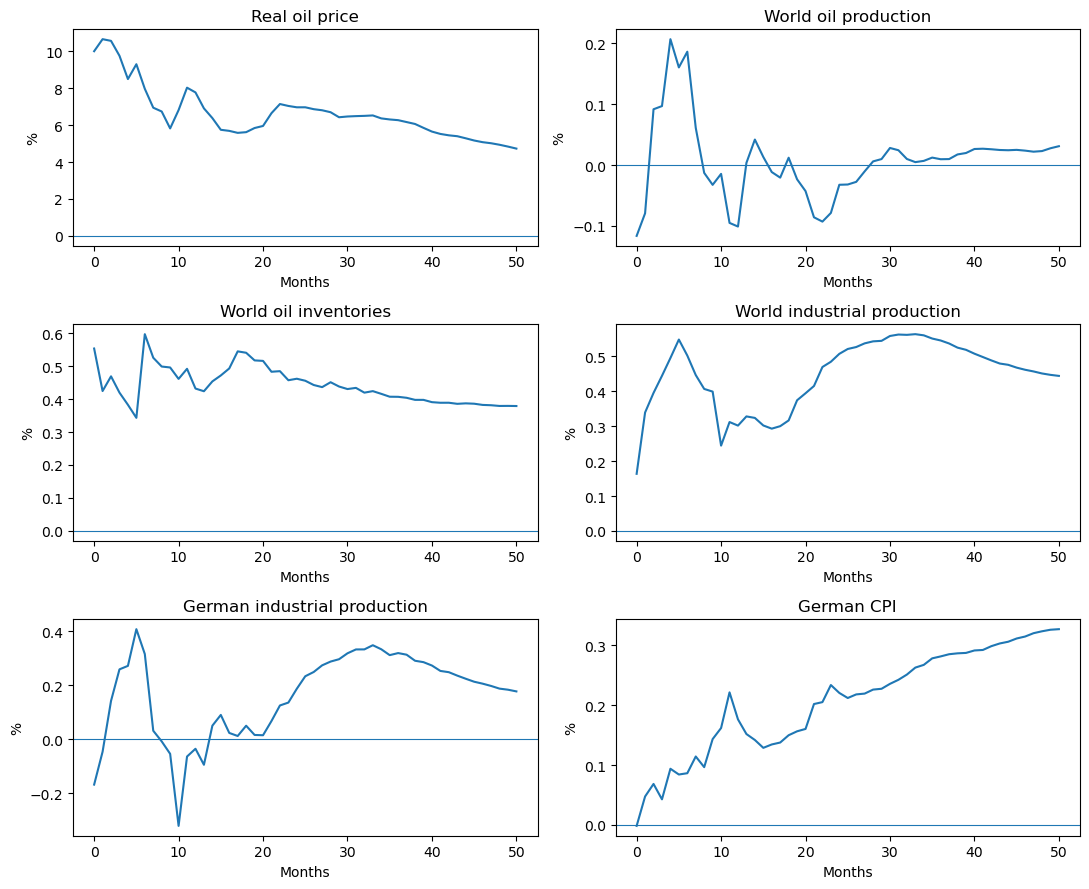

In [317]:
titles = {
    "world_oil_price": "Real oil price",
    "world_prod": "World oil production",
    "world_inv": "World oil inventories",
    "world_ip": "World industrial production",
    "ip_de": "German industrial production",
    "cpi_de": "German CPI"
}

fig, axes = plt.subplots(3, 2, figsize=(11, 9))
axes = axes.flatten()

for ax, col in zip(axes, baseline_cols):
    ax.plot(irf_baseline["horizon"], irf_baseline[col])
    ax.axhline(0, linewidth=0.8)
    ax.set_title(titles[col])
    ax.set_xlabel("Months")
    ax.set_ylabel("%")

plt.tight_layout()
fig.savefig(
    OUTPUT_DIR / "german_irf_cpi.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [ ]:
# ============================================================
# German baseline impulse responses
# ============================================================

import matplotlib.pyplot as plt

variable_titles = {
    "world_oil_price": "Real oil price",
    "world_prod": "World oil production",
    "world_inv": "World oil inventories",
    "world_ip": "World industrial production",
    "ip_de": "German industrial production",
    "cpi_de": "German CPI",
}

fig, axes = plt.subplots(
    3,
    2,
    figsize=(12, 10),
)

axes = axes.flatten()

for ax, variable in zip(
    axes,
    baseline_cols,
):

    ax.plot(
        irf_baseline["horizon"],
        irf_baseline[variable],
        linewidth=1.7,
    )

    ax.axhline(
        y=0,
        linewidth=0.8,
    )

    ax.set_title(
        variable_titles[variable]
    )

    ax.set_xlabel("Months")
    ax.set_ylabel("Percent")

    ax.grid(
        alpha=0.2
    )

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "german_irf_cpi.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## **10. Next Steps: German Pricing-Chain Extensions**

After validating the baseline German model, the same Proxy-SVAR procedure will be applied to two augmented systems:

1. **Baseline + import prices** — captures the first domestic stage of pass-through from global oil prices;
2. **Baseline + producer prices** — captures transmission into firms' output prices.

The resulting responses of import prices, producer prices, and CPI can then be compared in terms of:
- impact response;
- time to peak;
- peak magnitude;
- persistence.

A final step will add bootstrap confidence intervals and, if useful, robustness checks for alternative lag lengths or samples.


### **10.1 Baseline + German Import Prices**

To study the first stage of domestic price pass-through, we augment the six-variable German baseline VAR with the German import price index.

The augmented system is

$$
y_t =
\begin{bmatrix}
\text{Real oil price} \\
\text{World oil production} \\
\text{World oil inventories} \\
\text{World industrial production} \\
\text{German industrial production} \\
\text{German CPI} \\
\text{German import prices}
\end{bmatrix}.
$$

The identification strategy remains unchanged: the Brent oil supply news series is used as an external instrument for the structural oil supply news shock. The shock is again normalized to increase the real oil price by 10 percent on impact.

In [318]:
import_cols = baseline_cols + ["import_price_de"]

import_de = (
    data_germany[["date"] + import_cols]
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)

print(import_de.shape)
print(import_de["date"].min(), import_de["date"].max())

(324, 8)
1991-01 2017-12


In [319]:
var_import_model = VAR(import_de[import_cols])

var_import_res = var_import_model.fit(
    maxlags=12,
    trend="c"
)

print(var_import_res.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 02, Sep, 2026
Time:                     12:59:21
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                    5.73559
Nobs:                     312.000    HQIC:                   1.45037
Log likelihood:          -2285.17    FPE:                   0.271523
AIC:                     -1.40251    Det(Omega_mle):       0.0502753
--------------------------------------------------------------------
Results for equation world_oil_price
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const                     588.573118       423.406786            1.390           0.165
L1.world_oil_price          1.074208         0.093374           11.504           0.000
L1.world_prod             

In [320]:
u_import = var_import_res.resid.copy()

u_import["date"] = import_de.loc[
    u_import.index, "date"
].values

print(
    "Residual sample:",
    u_import["date"].min(),
    "-",
    u_import["date"].max()
)

display(u_import.head())

Residual sample: 1992-01 - 2017-12


,world_oil_price,world_prod,world_inv,world_ip,ip_de,cpi_de,import_price_de,date
12,-4.695785,1.066389,0.253282,-0.143018,1.876332,0.115659,-0.018696,1992-01
13,1.516575,-0.267238,0.714871,0.366547,2.137404,0.032858,0.446024,1992-02
14,-8.316946,-0.304789,-0.484730,-0.052269,0.167050,-0.210251,-0.270102,1992-03
15,2.192097,1.156685,-0.250446,-0.091306,-0.919747,-0.152958,-0.122848,1992-04
16,2.913157,-0.763652,-0.075950,0.286333,0.018413,-0.009676,0.710164,1992-05


In [321]:
proxy_sample_import = (
    u_import
    .merge(
        brent_proxy_rep[["date", "proxy"]],
        on="date",
        how="inner"
    )
    .dropna()
    .reset_index(drop=True)
)

print(
    "Identification sample:",
    proxy_sample_import["date"].min(),
    "-",
    proxy_sample_import["date"].max()
)

print("N =", len(proxy_sample_import))
print(
    "Non-zero proxy months =",
    (proxy_sample_import["proxy"] != 0).sum()
)

Identification sample: 1992-01 - 2017-11
N = 311
Non-zero proxy months = 91


In [322]:
X_import = sm.add_constant(
    proxy_sample_import["proxy"]
)

first_stage_import = sm.OLS(
    proxy_sample_import["world_oil_price"],
    X_import
).fit()

first_stage_import_robust = sm.OLS(
    proxy_sample_import["world_oil_price"],
    X_import
).fit(cov_type="HC1")

F_standard_import = first_stage_import.fvalue
F_robust_import = (
    first_stage_import_robust.tvalues["proxy"] ** 2
)

print(
    f"First-stage coefficient: "
    f"{first_stage_import_robust.params['proxy']:.4f}"
)

print(
    f"Standard F-statistic:    "
    f"{F_standard_import:.2f}"
)

print(
    f"Robust F-statistic:      "
    f"{F_robust_import:.2f}"
)

print(
    f"R-squared:               "
    f"{first_stage_import.rsquared:.4f}"
)

First-stage coefficient: 0.2664
Standard F-statistic:    8.28
Robust F-statistic:      6.65
R-squared:               0.0261


In [323]:
z_import = proxy_sample_import[
    "proxy"
].to_numpy()

cov_zu_import = np.array([
    np.cov(
        z_import,
        proxy_sample_import[col].to_numpy(),
        ddof=0
    )[0, 1]
    for col in import_cols
])

relative_impact_import = (
    cov_zu_import / cov_zu_import[0]
)

impact_vector_import = (
    10 * relative_impact_import
)

impact_table_import = pd.DataFrame({
    "variable": import_cols,
    "relative_impact": relative_impact_import,
    "impact": impact_vector_import
})

display(impact_table_import)

,variable,relative_impact,impact
0,world_oil_price,1.000000,10.000000
1,world_prod,-0.013997,-0.139973
2,world_inv,0.061971,0.619711
3,world_ip,0.016910,0.169102
4,ip_de,-0.020842,-0.208418
5,cpi_de,-0.001873,-0.018727
6,import_price_de,0.092981,0.929805


In [324]:
horizon = 50

ma_import = var_import_res.ma_rep(
    maxn=horizon
)

irfs_import = np.array([
    ma_import[h] @ impact_vector_import
    for h in range(horizon + 1)
])

irf_import = pd.DataFrame(
    irfs_import,
    columns=import_cols
)

irf_import.insert(
    0,
    "horizon",
    np.arange(horizon + 1)
)

display(irf_import.head())

,horizon,world_oil_price,world_prod,world_inv,world_ip,ip_de,cpi_de,import_price_de
0,0,10.000000,-0.139973,0.619711,0.169102,-0.208418,-0.018727,0.929805
1,1,10.454340,-0.145163,0.508894,0.361392,0.040400,0.083932,1.253122
2,2,10.271962,0.012332,0.576793,0.401773,0.244192,0.140857,1.382128
3,3,8.254887,-0.065598,0.450586,0.417268,0.465670,0.120735,1.192686
4,4,6.629831,-0.126930,0.338518,0.391901,0.570119,0.176925,0.994411


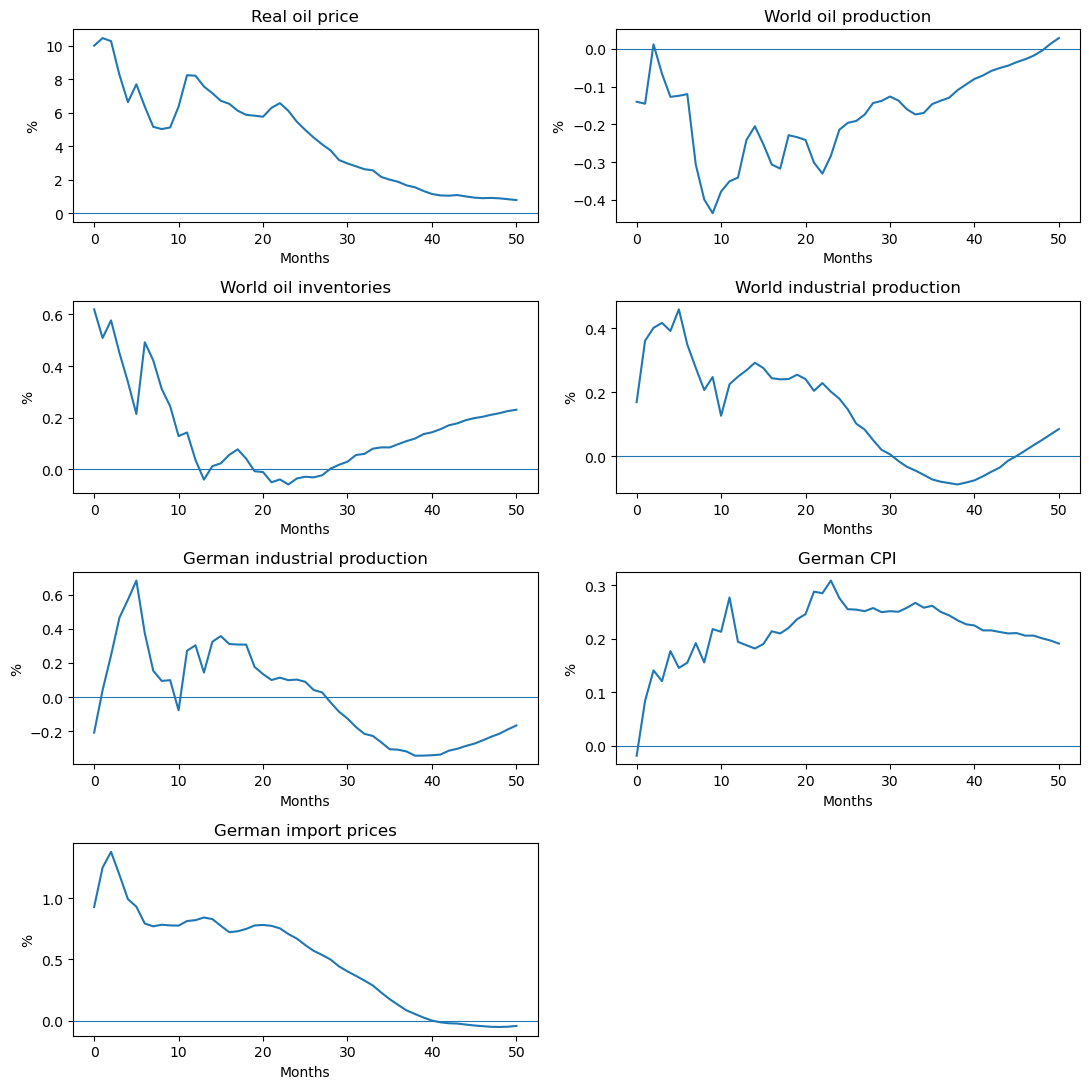

In [325]:
titles_import = {
    "world_oil_price": "Real oil price",
    "world_prod": "World oil production",
    "world_inv": "World oil inventories",
    "world_ip": "World industrial production",
    "ip_de": "German industrial production",
    "cpi_de": "German CPI",
    "import_price_de": "German import prices"
}

fig, axes = plt.subplots(
    4, 2,
    figsize=(11, 11)
)

axes = axes.flatten()

for ax, col in zip(
    axes,
    import_cols
):
    ax.plot(
        irf_import["horizon"],
        irf_import[col]
    )
    ax.axhline(
        0,
        linewidth=0.8
    )
    ax.set_title(
        titles_import[col]
    )
    ax.set_xlabel(
        "Months"
    )
    ax.set_ylabel(
        "%"
    )

# Hide unused subplot
for ax in axes[len(import_cols):]:
    ax.set_visible(False)

plt.tight_layout()
fig.savefig(
    OUTPUT_DIR / "german_irf_cpi_imp.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### **10.2 Baseline + German Producer Prices**

To examine the next stage of domestic price transmission, we augment the six-variable German baseline VAR with the German producer price index (PPI).

The augmented system is

$$
y_t =
\begin{bmatrix}
\text{Real oil price} \\
\text{World oil production} \\
\text{World oil inventories} \\
\text{World industrial production} \\
\text{German industrial production} \\
\text{German CPI} \\
\text{German producer prices}
\end{bmatrix}.
$$

The identification strategy remains unchanged. The Brent oil supply news series is used as an external instrument for the structural oil supply news shock, which is normalized to increase the real oil price by 10 percent on impact.

Comparing the PPI response with the previously estimated import-price and CPI responses allows us to examine how an oil supply news shock propagates through different stages of the German pricing chain.

In [326]:
ppi_cols = baseline_cols + ["ppi_de"]

ppi_de = (
    data_germany[["date"] + ppi_cols]
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)

print("Sample:", ppi_de["date"].min(), "-", ppi_de["date"].max())
print("Observations:", len(ppi_de))

Sample: 1991-01 - 2017-12
Observations: 324


In [327]:
var_ppi_model = VAR(ppi_de[ppi_cols])

var_ppi_res = var_ppi_model.fit(
    maxlags=12,
    trend="c"
)

print(var_ppi_res.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 02, Sep, 2026
Time:                     12:59:22
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                    4.80440
Nobs:                     312.000    HQIC:                  0.519178
Log likelihood:          -2139.90    FPE:                   0.107003
AIC:                     -2.33370    Det(Omega_mle):       0.0198127
--------------------------------------------------------------------
Results for equation world_oil_price
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const                     646.905269       352.168132            1.837           0.066
L1.world_oil_price          1.034972         0.077170           13.411           0.000
L1.world_prod             

In [328]:
u_ppi = var_ppi_res.resid.copy()

u_ppi["date"] = ppi_de.loc[
    u_ppi.index, "date"
].values

print(
    "Residual sample:",
    u_ppi["date"].min(),
    "-",
    u_ppi["date"].max()
)

display(u_ppi.head())

Residual sample: 1992-01 - 2017-12


,world_oil_price,world_prod,world_inv,world_ip,ip_de,cpi_de,ppi_de,date
12,-1.460802,0.552740,0.229024,0.119618,2.476460,0.261715,0.202097,1992-01
13,2.019389,0.133206,0.597881,0.291740,2.238174,0.075695,0.060467,1992-02
14,-5.520178,-0.271389,-0.457091,-0.051358,0.212964,-0.144446,-0.007594,1992-03
15,2.453240,1.152042,-0.235517,-0.091862,-1.047660,-0.068471,0.173059,1992-04
16,1.507569,-0.775896,-0.273611,0.125584,0.104112,-0.006095,-0.204601,1992-05


In [329]:
proxy_sample_ppi = (
    u_ppi
    .merge(
        brent_proxy_rep[["date", "proxy"]],
        on="date",
        how="inner"
    )
    .dropna()
    .reset_index(drop=True)
)

print(
    "Identification sample:",
    proxy_sample_ppi["date"].min(),
    "-",
    proxy_sample_ppi["date"].max()
)

print("N =", len(proxy_sample_ppi))
print(
    "Non-zero proxy months =",
    (proxy_sample_ppi["proxy"] != 0).sum()
)

Identification sample: 1992-01 - 2017-11
N = 311
Non-zero proxy months = 91


In [330]:
X_ppi = sm.add_constant(
    proxy_sample_ppi["proxy"]
)

first_stage_ppi = sm.OLS(
    proxy_sample_ppi["world_oil_price"],
    X_ppi
).fit()

first_stage_ppi_robust = sm.OLS(
    proxy_sample_ppi["world_oil_price"],
    X_ppi
).fit(cov_type="HC1")

F_standard_ppi = first_stage_ppi.fvalue

F_robust_ppi = (
    first_stage_ppi_robust.tvalues["proxy"] ** 2
)

print(
    f"First-stage coefficient: "
    f"{first_stage_ppi_robust.params['proxy']:.4f}"
)

print(
    f"Standard F-statistic:    "
    f"{F_standard_ppi:.2f}"
)

print(
    f"Robust F-statistic:      "
    f"{F_robust_ppi:.2f}"
)

print(
    f"R-squared:               "
    f"{first_stage_ppi.rsquared:.4f}"
)

First-stage coefficient: 0.2596
Standard F-statistic:    7.80
Robust F-statistic:      5.74
R-squared:               0.0246


In [331]:
z_ppi = proxy_sample_ppi[
    "proxy"
].to_numpy()

cov_zu_ppi = np.array([
    np.cov(
        z_ppi,
        proxy_sample_ppi[col].to_numpy(),
        ddof=0
    )[0, 1]
    for col in ppi_cols
])

relative_impact_ppi = (
    cov_zu_ppi / cov_zu_ppi[0]
)

# Normalize to +10% oil-price response on impact
impact_vector_ppi = (
    10 * relative_impact_ppi
)

impact_table_ppi = pd.DataFrame({
    "variable": ppi_cols,
    "relative_impact": relative_impact_ppi,
    "impact": impact_vector_ppi
})

display(impact_table_ppi)

,variable,relative_impact,impact
0,world_oil_price,1.000000,10.000000
1,world_prod,-0.004317,-0.043169
2,world_inv,0.067148,0.671478
3,world_ip,0.012674,0.126739
4,ip_de,-0.026782,-0.267818
5,cpi_de,0.001202,0.012020
6,ppi_de,0.032420,0.324196


In [332]:
horizon = 50

ma_ppi = var_ppi_res.ma_rep(
    maxn=horizon
)

irfs_ppi = np.array([
    ma_ppi[h] @ impact_vector_ppi
    for h in range(horizon + 1)
])

irf_ppi = pd.DataFrame(
    irfs_ppi,
    columns=ppi_cols
)

irf_ppi.insert(
    0,
    "horizon",
    np.arange(horizon + 1)
)

display(irf_ppi.head())

,horizon,world_oil_price,world_prod,world_inv,world_ip,ip_de,cpi_de,ppi_de
0,0,10.000000,-0.043169,0.671478,0.126739,-0.267818,0.012020,0.324196
1,1,10.391555,-0.048389,0.561002,0.288472,-0.074730,0.061401,0.430364
2,2,9.767958,0.037632,0.628606,0.279188,0.042140,0.096632,0.500346
3,3,8.268841,-0.008173,0.582451,0.291997,0.185348,0.058108,0.530080
4,4,6.763703,0.112524,0.519353,0.303389,0.082098,0.099243,0.513008


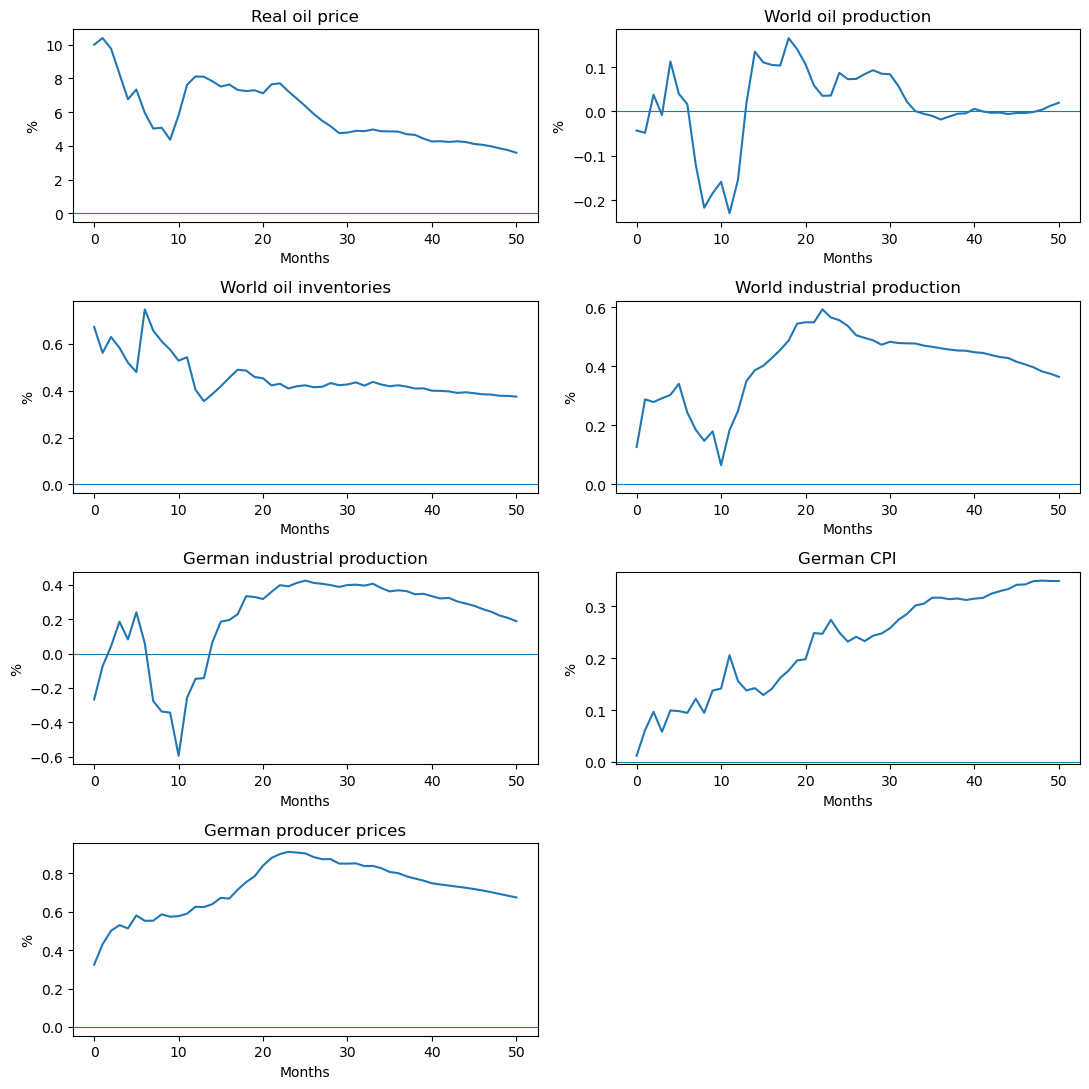

In [333]:
titles_ppi = {
    "world_oil_price": "Real oil price",
    "world_prod": "World oil production",
    "world_inv": "World oil inventories",
    "world_ip": "World industrial production",
    "ip_de": "German industrial production",
    "cpi_de": "German CPI",
    "ppi_de": "German producer prices"
}

fig, axes = plt.subplots(
    4, 2,
    figsize=(11, 11)
)

axes = axes.flatten()

for ax, col in zip(axes, ppi_cols):

    ax.plot(
        irf_ppi["horizon"],
        irf_ppi[col]
    )

    ax.axhline(
        0,
        linewidth=0.8
    )

    ax.set_title(
        titles_ppi[col]
    )

    ax.set_xlabel("Months")
    ax.set_ylabel("%")

for ax in axes[len(ppi_cols):]:
    ax.set_visible(False)

plt.tight_layout()
fig.savefig(
    OUTPUT_DIR / "german_irf_cpi_prodp.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

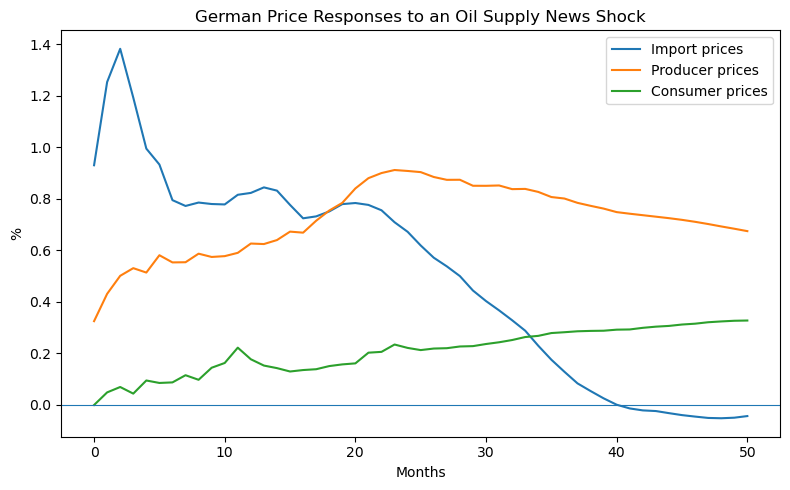

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    irf_import["horizon"],
    irf_import["import_price_de"],
    label="Import prices"
)

ax.plot(
    irf_ppi["horizon"],
    irf_ppi["ppi_de"],
    label="Producer prices"
)

ax.plot(
    irf_baseline["horizon"],
    irf_baseline["cpi_de"],
    label="Consumer prices"
)

ax.axhline(0, linewidth=0.8)

ax.set_xlabel("Months")
ax.set_ylabel("%")
#ax.set_title(
#    "German Price Responses to an Oil Supply News Shock"
#)

ax.legend()

plt.tight_layout()
fig.savefig(
    OUTPUT_DIR / "german_irf_cpi_imp_prodp.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

* Import prices react almost immediately. They rise by about 0.9% on impact, peak near 1.4% after roughly 2 months, and then gradually decline toward zero.
* Producer prices react more slowly. The impact response is only around 0.3%, but the response builds over time and peaks around 0.9% after approximately 23–25 months. It remains elevated even after 50 months.
* Consumer prices have essentially no impact response. Their response increases gradually and reaches roughly 0.3% by the end of the horizon.

In [ ]:
# ============================================================
# German price responses to an oil supply news shock
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

# Import prices
ax.plot(
    irf_import["horizon"],
    irf_import["import_price_de"],
    linewidth=1.7,
    label="Import prices",
)

# Producer prices
ax.plot(
    irf_ppi["horizon"],
    irf_ppi["ppi_de"],
    linewidth=1.7,
    label="Producer prices",
)

# Consumer prices
ax.plot(
    irf_baseline["horizon"],
    irf_baseline["cpi_de"],
    linewidth=1.7,
    label="Consumer prices",
)

ax.axhline(
    y=0,
    linewidth=0.8,
)

ax.set_xlabel("Months")
ax.set_ylabel("Percent")

ax.grid(
    alpha=0.2
)

ax.legend(
    frameon=False
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "german_irf_cpi_imp_prodp.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [343]:
def summarize_price_irf(irf_df, variable, label):
    """
    Summarize the response of a price variable to the oil supply news shock.
    """

    response = irf_df[variable].to_numpy()
    horizons = irf_df["horizon"].to_numpy()

    peak_idx = np.argmax(response)

    return {
        "Price index": label,
        "Impact": response[0],
        "Peak response": response[peak_idx],
        "Months to peak": horizons[peak_idx],
        "12 months": response[12],
        "24 months": response[24]
    }


price_pass_through = pd.DataFrame([
    summarize_price_irf(
        irf_import,
        "import_price_de",
        "Import prices"
    ),
    summarize_price_irf(
        irf_ppi,
        "ppi_de",
        "Producer prices"
    ),
    summarize_price_irf(
        irf_baseline,
        "cpi_de",
        "Consumer prices"
    )
])

price_pass_through

,Price index,Impact,Peak response,Months to peak,12 months,24 months
0,Import prices,0.929805,1.382128,2,0.822381,0.671330
1,Producer prices,0.324196,0.911315,23,0.625716,0.907631
2,Consumer prices,-0.001529,0.326700,50,0.176187,0.220309


In [344]:
price_pass_through_formatted = price_pass_through.copy()

for col in [
    "Impact",
    "Peak response",
    "12 months",
    "24 months"
]:
    price_pass_through_formatted[col] = (
        price_pass_through_formatted[col].round(2)
    )

price_pass_through_formatted["Months to peak"] = (
    price_pass_through_formatted["Months to peak"].astype(int)
)

price_pass_through_formatted

,Price index,Impact,Peak response,Months to peak,12 months,24 months
0,Import prices,0.93,1.38,2,0.82,0.67
1,Producer prices,0.32,0.91,23,0.63,0.91
2,Consumer prices,-0.00,0.33,50,0.18,0.22


In [345]:
print(
    price_pass_through_formatted.to_latex(
        index=False,
        escape=False,
        column_format="lccccc",
        float_format="%.2f"
    )
)

\begin{tabular}{lccccc}
\toprule
Price index & Impact & Peak response & Months to peak & 12 months & 24 months \\
\midrule
Import prices & 0.93 & 1.38 & 2 & 0.82 & 0.67 \\
Producer prices & 0.32 & 0.91 & 23 & 0.63 & 0.91 \\
Consumer prices & -0.00 & 0.33 & 50 & 0.18 & 0.22 \\
\bottomrule
\end{tabular}



## 11. Bootstrap Confidence Intervals

In [335]:
from statsmodels.tsa.api import VAR

def moving_block_indices(T, block_length, rng):
    """
    Draw indices for a moving-block bootstrap sample of length T.
    """
    n_blocks = int(np.ceil(T / block_length))
    starts = rng.integers(
        0,
        T - block_length + 1,
        size=n_blocks
    )

    indices = np.concatenate([
        np.arange(s, s + block_length)
        for s in starts
    ])

    return indices[:T]

In [336]:
def bootstrap_proxy_svar_irfs(
    df,
    variables,
    proxy_df,
    proxy_col="proxy",
    lags=12,
    horizon=50,
    shock_size=10,
    n_boot=1000,
    block_length=12,
    seed=1234
):
    """
    Moving-block bootstrap confidence intervals for a Proxy SVAR.

    Parameters
    ----------
    df : DataFrame
        Contains `date` plus the VAR variables.

    variables : list
        Ordered list of VAR variables. The first variable is the
        oil-price variable instrumented by the proxy.

    proxy_df : DataFrame
        Contains `date` and the external instrument.

    lags : int
        VAR lag length.

    horizon : int
        Maximum IRF horizon.

    shock_size : float
        Normalization of the impact oil-price response.

    n_boot : int
        Number of bootstrap replications.

    block_length : int
        Length of moving bootstrap blocks.

    seed : int
        Random seed.
    """

    rng = np.random.default_rng(seed)

    # ---------------------------------------------------
    # 1. Estimate original reduced-form VAR
    # ---------------------------------------------------
    Y = df[variables].reset_index(drop=True)

    model = VAR(Y)
    res = model.fit(
        maxlags=lags,
        trend="c"
    )

    residuals = res.resid.to_numpy()
    T_res = residuals.shape[0]
    K = len(variables)

    # Dates corresponding to VAR residuals
    residual_dates = (
        df["date"]
        .iloc[lags:]
        .reset_index(drop=True)
    )

    # ---------------------------------------------------
    # 2. Align original proxy with residual sample
    # ---------------------------------------------------
    proxy_aligned = (
        pd.DataFrame({
            "date": residual_dates
        })
        .merge(
            proxy_df[["date", proxy_col]],
            on="date",
            how="left"
        )
    )

    z_original = proxy_aligned[proxy_col].to_numpy()

    # ---------------------------------------------------
    # 3. Store estimated VAR coefficients
    # ---------------------------------------------------
    intercept = res.intercept.copy()
    coefs = res.coefs.copy()

    Y_original = Y.to_numpy()

    # Keep initial observations to initialize simulations
    initial_values = Y_original[:lags].copy()

    boot_irfs = np.full(
        (n_boot, horizon + 1, K),
        np.nan
    )

    successful = 0

    # ---------------------------------------------------
    # 4. Bootstrap loop
    # ---------------------------------------------------
    for b in range(n_boot):

        # Jointly resample residuals AND proxy in blocks.
        # This preserves their contemporaneous relationship.
        idx = moving_block_indices(
            T=T_res,
            block_length=block_length,
            rng=rng
        )

        u_star = residuals[idx, :]
        z_star = z_original[idx]

        # -----------------------------------------------
        # Generate artificial VAR sample
        # -----------------------------------------------
        Y_star = np.zeros_like(Y_original)
        Y_star[:lags] = initial_values

        for t in range(lags, len(Y_star)):

            y_t = intercept.copy()

            for L in range(1, lags + 1):
                y_t += (
                    coefs[L - 1]
                    @ Y_star[t - L]
                )

            y_t += u_star[t - lags]

            Y_star[t] = y_t

        # -----------------------------------------------
        # Re-estimate VAR
        # -----------------------------------------------
        try:
            boot_model = VAR(
                pd.DataFrame(
                    Y_star,
                    columns=variables
                )
            )

            boot_res = boot_model.fit(
                maxlags=lags,
                trend="c"
            )

        except Exception:
            continue

        u_boot = boot_res.resid.to_numpy()

        # -----------------------------------------------
        # Re-identify structural shock
        # -----------------------------------------------
        # z_star and u_boot have the same residual length
        if len(z_star) != len(u_boot):
            continue

        cov_zu = np.array([
            np.cov(
                z_star,
                u_boot[:, j],
                ddof=0
            )[0, 1]
            for j in range(K)
        ])

        # Avoid pathological bootstrap draws
        if (
            not np.all(np.isfinite(cov_zu))
            or abs(cov_zu[0]) < 1e-10
        ):
            continue

        relative_impact = (
            cov_zu / cov_zu[0]
        )

        impact_vector = (
            shock_size * relative_impact
        )

        # -----------------------------------------------
        # Bootstrap IRFs
        # -----------------------------------------------
        ma = boot_res.ma_rep(
            maxn=horizon
        )

        irfs_b = np.array([
            ma[h] @ impact_vector
            for h in range(horizon + 1)
        ])

        if np.all(np.isfinite(irfs_b)):
            boot_irfs[successful] = irfs_b
            successful += 1

    boot_irfs = boot_irfs[:successful]

    print(
        f"Successful bootstrap draws: "
        f"{successful}/{n_boot}"
    )

    # ---------------------------------------------------
    # 5. Percentile confidence intervals
    # ---------------------------------------------------
    bands = {
        "lower90": np.percentile(
            boot_irfs, 5, axis=0
        ),
        "lower68": np.percentile(
            boot_irfs, 16, axis=0
        ),
        "upper68": np.percentile(
            boot_irfs, 84, axis=0
        ),
        "upper90": np.percentile(
            boot_irfs, 95, axis=0
        ),
        "draws": boot_irfs
    }

    return bands

In [337]:
bands_baseline = bootstrap_proxy_svar_irfs(
    df=baseline_de,
    variables=baseline_cols,
    proxy_df=brent_proxy_rep,   # use your replicated Brent instrument
    proxy_col="proxy",
    lags=12,
    horizon=50,
    shock_size=10,
    n_boot=1000,
    block_length=12,
    seed=1234
)

Successful bootstrap draws: 916/1000


In [338]:
n_boot=1000

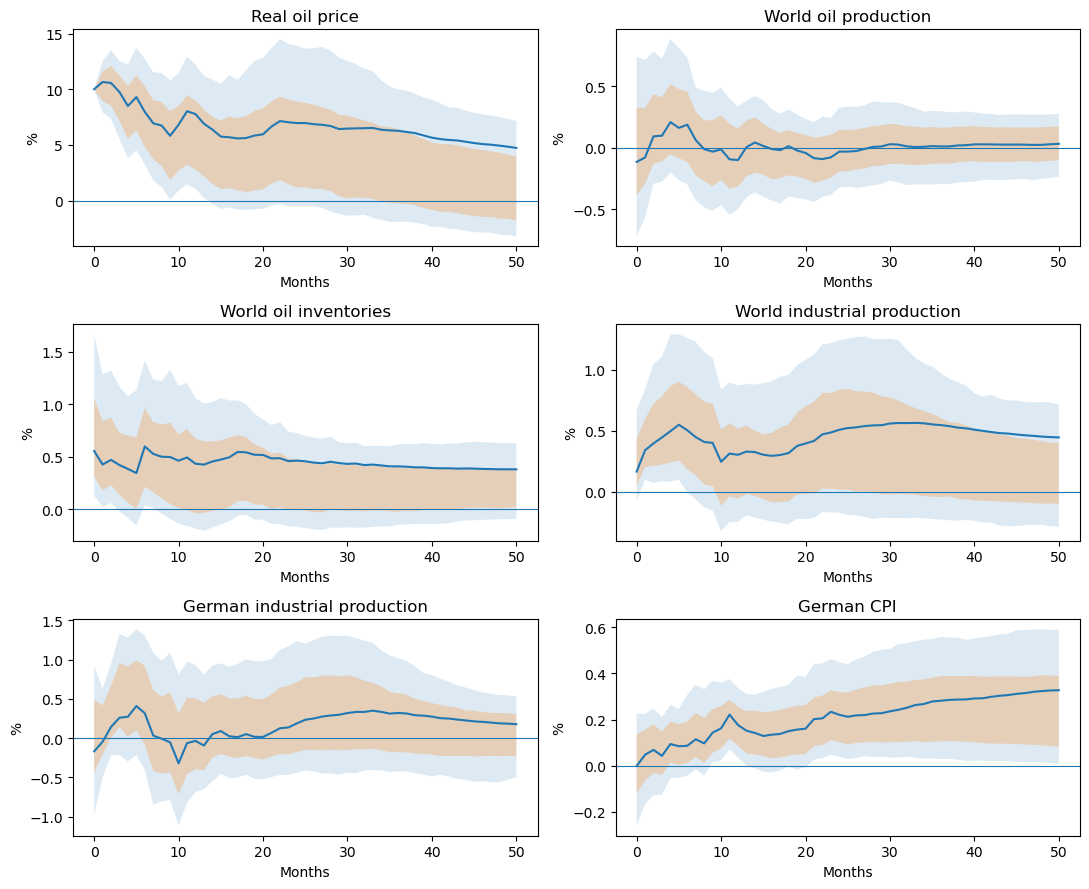

In [339]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(11, 9)
)

axes = axes.flatten()

h = np.arange(51)

for j, (ax, col) in enumerate(
    zip(axes, baseline_cols)
):

    # 90% band
    ax.fill_between(
        h,
        bands_baseline["lower90"][:, j],
        bands_baseline["upper90"][:, j],
        alpha=0.15
    )

    # 68% band
    ax.fill_between(
        h,
        bands_baseline["lower68"][:, j],
        bands_baseline["upper68"][:, j],
        alpha=0.25
    )

    # Point estimate
    ax.plot(
        irf_baseline["horizon"],
        irf_baseline[col],
        linewidth=1.5
    )

    ax.axhline(
        0,
        linewidth=0.8
    )

    ax.set_title(
        titles[col]
    )

    ax.set_xlabel(
        "Months"
    )

    ax.set_ylabel(
        "%"
    )

plt.tight_layout()
fig.savefig(
    OUTPUT_DIR / "german_irf_cpi_conf.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# ============================================================
# German baseline impulse responses with confidence intervals
# ============================================================

fig, axes = plt.subplots(
    3,
    2,
    figsize=(12, 10),
)

axes = axes.flatten()

h = np.arange(51)

for j, (ax, variable) in enumerate(
    zip(axes, baseline_cols)
):

    # 90% confidence interval
    ax.fill_between(
        h,
        bands_baseline["lower90"][:, j],
        bands_baseline["upper90"][:, j],
        alpha=0.15,
    )

    # 68% confidence interval
    ax.fill_between(
        h,
        bands_baseline["lower68"][:, j],
        bands_baseline["upper68"][:, j],
        alpha=0.25,
    )

    # Point estimate
    ax.plot(
        irf_baseline["horizon"],
        irf_baseline[variable],
        linewidth=1.7,
    )

    ax.axhline(
        y=0,
        linewidth=0.8,
    )

    ax.set_title(
        variable_titles[variable]
    )

    ax.set_xlabel("Months")
    ax.set_ylabel("Percent")

    ax.grid(
        alpha=0.2
    )

from matplotlib.patches import Patch

legend_elements = [
    Patch(alpha=0.25, label="68% confidence interval"),
    Patch(alpha=0.15, label="90% confidence interval"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
)

fig.tight_layout(
    rect=[0, 0.05, 1, 1]
)

fig.savefig(
    OUTPUT_DIR / "german_irf_cpi_conf.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [340]:
bands_import = bootstrap_proxy_svar_irfs(
    df=import_de,
    variables=import_cols,
    proxy_df=brent_proxy_rep,
    lags=12,
    horizon=50,
    n_boot=1000,
    block_length=12,
    seed=1234
)

Successful bootstrap draws: 916/1000


In [341]:
bands_ppi = bootstrap_proxy_svar_irfs(
    df=ppi_de,
    variables=ppi_cols,
    proxy_df=brent_proxy_rep,
    lags=12,
    horizon=50,
    n_boot=1000,
    block_length=12,
    seed=1234
)

Successful bootstrap draws: 916/1000


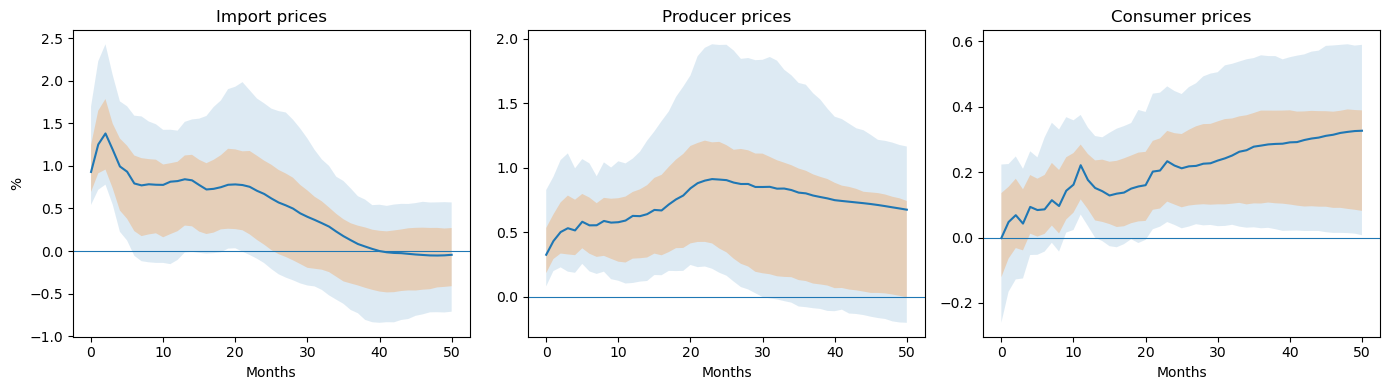

In [342]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 4)
)

# Import prices
j_import = import_cols.index(
    "import_price_de"
)

axes[0].fill_between(
    h,
    bands_import["lower90"][:, j_import],
    bands_import["upper90"][:, j_import],
    alpha=0.15
)

axes[0].fill_between(
    h,
    bands_import["lower68"][:, j_import],
    bands_import["upper68"][:, j_import],
    alpha=0.25
)

axes[0].plot(
    h,
    irf_import["import_price_de"]
)

axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("Import prices")
axes[0].set_xlabel("Months")
axes[0].set_ylabel("%")


# Producer prices
j_ppi = ppi_cols.index(
    "ppi_de"
)

axes[1].fill_between(
    h,
    bands_ppi["lower90"][:, j_ppi],
    bands_ppi["upper90"][:, j_ppi],
    alpha=0.15
)

axes[1].fill_between(
    h,
    bands_ppi["lower68"][:, j_ppi],
    bands_ppi["upper68"][:, j_ppi],
    alpha=0.25
)

axes[1].plot(
    h,
    irf_ppi["ppi_de"]
)

axes[1].axhline(0, linewidth=0.8)
axes[1].set_title("Producer prices")
axes[1].set_xlabel("Months")


# Consumer prices
j_cpi = baseline_cols.index(
    "cpi_de"
)

axes[2].fill_between(
    h,
    bands_baseline["lower90"][:, j_cpi],
    bands_baseline["upper90"][:, j_cpi],
    alpha=0.15
)

axes[2].fill_between(
    h,
    bands_baseline["lower68"][:, j_cpi],
    bands_baseline["upper68"][:, j_cpi],
    alpha=0.25
)

axes[2].plot(
    h,
    irf_baseline["cpi_de"]
)

axes[2].axhline(0, linewidth=0.8)
axes[2].set_title("Consumer prices")
axes[2].set_xlabel("Months")

plt.tight_layout()
fig.savefig(
    OUTPUT_DIR / "german_irf_cpi_impp_prodp_conf.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# ============================================================
# German price responses with confidence intervals
# ============================================================

from matplotlib.patches import Patch

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4),
)

# ------------------------------------------------------------
# Import prices
# ------------------------------------------------------------

j_import = import_cols.index(
    "import_price_de"
)

axes[0].fill_between(
    h,
    bands_import["lower90"][:, j_import],
    bands_import["upper90"][:, j_import],
    alpha=0.15,
)

axes[0].fill_between(
    h,
    bands_import["lower68"][:, j_import],
    bands_import["upper68"][:, j_import],
    alpha=0.25,
)

axes[0].plot(
    h,
    irf_import["import_price_de"],
    linewidth=1.7,
)

axes[0].axhline(
    y=0,
    linewidth=0.8,
)

axes[0].set_title("Import prices")
axes[0].set_xlabel("Months")
axes[0].set_ylabel("Percent")

axes[0].grid(
    alpha=0.2
)


# ------------------------------------------------------------
# Producer prices
# ------------------------------------------------------------

j_ppi = ppi_cols.index(
    "ppi_de"
)

axes[1].fill_between(
    h,
    bands_ppi["lower90"][:, j_ppi],
    bands_ppi["upper90"][:, j_ppi],
    alpha=0.15,
)

axes[1].fill_between(
    h,
    bands_ppi["lower68"][:, j_ppi],
    bands_ppi["upper68"][:, j_ppi],
    alpha=0.25,
)

axes[1].plot(
    h,
    irf_ppi["ppi_de"],
    linewidth=1.7,
)

axes[1].axhline(
    y=0,
    linewidth=0.8,
)

axes[1].set_title("Producer prices")
axes[1].set_xlabel("Months")

axes[1].grid(
    alpha=0.2
)


# ------------------------------------------------------------
# Consumer prices
# ------------------------------------------------------------

j_cpi = baseline_cols.index(
    "cpi_de"
)

axes[2].fill_between(
    h,
    bands_baseline["lower90"][:, j_cpi],
    bands_baseline["upper90"][:, j_cpi],
    alpha=0.15,
)

axes[2].fill_between(
    h,
    bands_baseline["lower68"][:, j_cpi],
    bands_baseline["upper68"][:, j_cpi],
    alpha=0.25,
)

axes[2].plot(
    h,
    irf_baseline["cpi_de"],
    linewidth=1.7,
)

axes[2].axhline(
    y=0,
    linewidth=0.8,
)

axes[2].set_title("Consumer prices")
axes[2].set_xlabel("Months")

axes[2].grid(
    alpha=0.2
)


# ------------------------------------------------------------
# Common legend
# ------------------------------------------------------------

legend_elements = [
    Patch(alpha=0.25, label="68% confidence interval"),
    Patch(alpha=0.15, label="90% confidence interval"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
)

fig.tight_layout(
    rect=[0, 0.10, 1, 1]
)

fig.savefig(
    OUTPUT_DIR / "german_irf_cpi_impp_prodp_conf.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()